# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA


| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [212]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [213]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data_2023.csv', sep=',', encoding='utf-8')

C:\Users\Tavo\AppData\Local\Temp\ipykernel_11140\4058249586.py:3: DtypeWarning: Columns (2,3,28,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data_2023.csv', sep=',', encoding='utf-8')


## **Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [214]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables couldn't be matched with Table definition
- ech
- RLFI

In the table definition, the following variables couldn't be matched
- Member State
- Version_file

In [215]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,NaN,143.0,NaN,NaN,NaN,petrol,M,999.0,81.0,NaN,e13 29,NaN,1.2,NaN,NaN,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,NaN,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,NaN,145.0,NaN,NaN,NaN,petrol,H,1598.0,132.0,NaN,e5 28,NaN,0.8,NaN,NaN,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,NaN,106.0,NaN,NaN,NaN,petrol,H,999.0,52.0,NaN,e3 33,NaN,1.3,NaN,NaN,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,NaN,131.0,NaN,NaN,NaN,petrol,M,1332.0,103.0,NaN,e9 29 37,NaN,1.9,NaN,NaN,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,NaN,158.0,NaN,NaN,NaN,diesel,H,1968.0,150.0,NaN,e13 33 37,NaN,2.0,NaN,NaN,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734651,134791605,PT,IP-EHT____ML6_722D-YAR-0,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e2*2007/46*0537*19,V,E,EHTM-P2S20L(1V),TOYOTA,PROACE,M1,M1,1,1808.0,2140.0,NaN,193.0,NaN,NaN,NaN,DIESEL,M,1997.0,106.0,NaN,e2 33,NaN,1.1,NaN,NaN,P,2023,2023-12-28,7.4,NaN,NaN,NaN
10734652,134793098,PT,IP-0200-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0318*07,ZE1HE(EU M),ZWE219(W),ZWE219L-DWXNBW(2H),TOYOTA,TOYOTA COROLLA,M1,M1,1,1475.0,1574.0,NaN,106.0,NaN,NaN,NaN,PETROL,H,1798.0,72.0,NaN,e6 37,NaN,0.6,NaN,NaN,P,2023,2023-09-01,4.7,NaN,NaN,NaN
10734653,134794448,PT,IP-0206-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA MOTOR CORPORATION,TOYOTA MOTOR CORPORATION,NaN,e6*2018/858*00260*00,XW6(M),MXWH61(H),MXWH61L-AHXHBW(1A),TOYOTA,TOYOTA PRIUS PHEV,M1,M1,1,1630.0,1753.0,NaN,16.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,1987.0,111.0,126.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-11-16,0.7,NaN,NaN,72.0
10734654,134795081,PT,IP-0120-JT1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*03,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1D),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,171.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-12-21,1.0,NaN,NaN,75.0
10734655,134796702,PT,IP-0120-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*02,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1C),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,166.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-10-31,1.0,NaN,NaN,75.0


### Data Translation

In [ ]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Fuel consumption ':'Fuel_consumption',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [217]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [218]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel_consumption', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

In [219]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [220]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734656           0              0.0
                                    Country    object        10734656           0              0.0
                   Vehicle_Family_id_number    object        10141479      593177              5.5
                       Manufacturer_Pooling    object         9777534      957122              8.9
                          Manufacturer_Name    object        10734656           0              0.0
                      Manufacturer_name_OEM    object        10734656           0              0.0
                       Manufacturer_name_MS   float64               0    10734656            100.0
                       Type_approval_number    object        10702002       32654              0.3
                                       Type    object        10728379        6277              0.1
          

 Missing Data Analysis - Key Insights:

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

Electric Vehicle Features (High Missing %):

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Most probably the non-Electric Vehicles do not have the respective features. It should be double checked

Important Features (Moderate Missing):

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

Clean Features (Low Missing):

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [221]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [222]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

In [223]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

In [224]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel_consumption,Electric range (km)
count,10713765.0,10713765.0,10713365.0,10205226.0,10713765.0,9043496.0,10678848.0,2359609.0,5767272.0,10713765.0,7547786.0,2334701.0
mean,125983907.2,1.0,1545.6,1655.8,106.7,1543.2,115.2,171.9,1.5,2023.0,5.4,318.2
std,8060129.8,0.0,360.7,374.1,59.6,524.2,62.4,28.9,0.5,0.0,1.8,191.8
min,90240411.0,1.0,563.0,615.0,0.0,658.0,8.0,11.0,0.5,2023.0,0.1,12.0
25%,122188940.0,1.0,1270.0,1376.0,101.0,1197.0,74.0,155.0,1.1,2023.0,4.9,77.0
50%,128890021.0,1.0,1480.0,1584.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,380.0
75%,131879745.0,1.0,1765.0,1881.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.1,491.0
max,134796702.0,1.0,4953.0,4574.0,543.0,7993.0,1177.0,547.0,7.0,2023.0,29.0,883.0


The following numerical columns have only 1 value and they will not be used in modeling steps
- Total_new_registrations
- year

In [225]:
df_a.shape

(10713765, 32)

In [226]:
df_a.head(5)

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,143.0,petrol,M,999.0,81.0,NaN,e13 29,1.2,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,145.0,petrol,H,1598.0,132.0,NaN,e5 28,0.8,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,106.0,petrol,H,999.0,52.0,NaN,e3 33,1.3,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,131.0,petrol,M,1332.0,103.0,NaN,e9 29 37,1.9,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,158.0,diesel,H,1968.0,150.0,NaN,e13 33 37,2.0,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


### Some Notes
- Not sure if Category_type_registered & Category_type_approved mean the same and how to interpret them

- Some name related fixes are necessary for Fuel_Type

- Fuel_Mode & Fuel_Type relation should be clarified

- How to translate Innovative technologies and it's impact 
- How to translate Emmission_reduction_through_innovation_WLTP 
- Is there any relationship between respective variables?

- Electric_Charge, RLFI, Electric range (km) they could be electricty-only related features

In [227]:
pd.crosstab(df_a['Category_type_registered'], 
           df_a['Category_type_approved'], 
           margins=True)

# Not sure about the meaning of these columns, so dropping them might be a good idea

Category_type_approved,M1,M1G,N1,N1G,N2,N2G,All
Category_type_registered,,,,,,,
M1,10323448,3048,423,4,2,0,10326925
M1G,1519,372010,0,22,0,1,373552
All,10324967,375058,423,26,2,1,10700477


In [228]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol             6003101
diesel             1821098
electric           1669449
petrol/electric     826370
lpg                 309128
e85                  46157
diesel/electric      30264
ng                    7362
hydrogen               730
PETROL                  59
PETROL/ELECTRIC         28
DIESEL                  17
ELECTRIC                 1
LPG                      1
Name: count, dtype: int64

In [229]:
# Create a mapping dictionary for standardization
fuel_mapping = {
    'PETROL': 'petrol',
    'DIESEL': 'diesel', 
    'ELECTRIC': 'electric',
    'PETROL/ELECTRIC': 'petrol/electric',
    'LPG': 'lpg',
    'e85': 'petrol'
}

# Apply the mapping
df_a['Fuel_Type'] = df_a['Fuel_Type'].replace(fuel_mapping)

# Check the result
print(df_a['Fuel_Type'].value_counts())

Fuel_Type
petrol             6049317
diesel             1821115
electric           1669450
petrol/electric     826398
lpg                 309129
diesel/electric      30264
ng                    7362
hydrogen               730
Name: count, dtype: int64


## Delete?

In [230]:
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Fuel_Mode'], 
           margins=True)

# How to map the respective varibles should be thought through

Fuel_Mode,B,E,F,H,M,P,All
Fuel_Type,,,,,,,
diesel,0,0,0,441320,1379795,0,1821115
diesel/electric,0,0,0,0,0,30264,30264
electric,0,1669450,0,0,0,0,1669450
hydrogen,1,0,0,0,729,0,730
lpg,309022,0,0,0,107,0,309129
ng,588,0,0,0,6774,0,7362
petrol,0,0,7325,2304275,3737717,0,6049317
petrol/electric,0,0,0,0,0,826398,826398
All,309611,1669450,7325,2745595,5125122,856662,10713765


In [231]:
# Checking electic related variables 
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Electric_Charge'], 
           margins=True)
# Electric_Charge is not only relevant for electric vehicles


Electric_Charge,2018/1832AP,2018/1832AX,6EA,AP,AR,AX,AY,AZ,EA,EU 2018/1832AP,EURO 6 AP,EURO 6 AQ,EURO 6 AR,EURO 6 AX,EURO 6 AZ,EURO 6 CI,EURO 6 EA,EURO 6AP,EURO 6AZ,EURO 6D,EURO 6EA,EURO AX,EURO AY,EURO VI,EURO VI E,EURO VIE,Euro 6,Euro 6 AP,Euro 6 AQ,Euro 6 AR,Euro 6 EA,Euro AX,Euro VI,Euro VI E,RL-0067-JT1-1,VI-E,All
Fuel_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
diesel,35,0,0,25393,4,0,0,0,468,0,56445,6,41,0,0,1,887,173984,0,0,3183,0,0,0,55,0,329,259493,1,5,7429,0,0,39,0,0,527798
diesel/electric,0,0,0,190,0,0,0,0,0,0,3108,0,0,0,0,0,2,1712,0,0,1,0,0,0,0,0,0,5047,0,0,4,0,0,0,0,0,10064
electric,0,7,0,76,0,427601,0,0,0,0,0,0,1,4182,0,0,0,0,0,0,0,55110,0,5,82,169,0,26033,0,0,0,1,10,626,0,1,513904
hydrogen,0,0,0,0,0,0,317,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0,1,0,0,0,0,0,0,0,0,326
lpg,0,0,0,6054,0,0,0,0,200,0,4180,0,0,0,0,0,2,25654,0,1,540,0,0,0,0,0,0,63236,0,0,657,0,0,0,0,0,100524
ng,0,0,0,502,0,0,0,0,0,0,157,0,0,0,0,0,0,145,0,0,0,0,0,0,0,0,0,172,0,0,0,0,0,0,0,0,976
petrol,702,0,3,119290,0,1,0,178,459,1,304837,0,0,0,2,0,3158,640313,41,2,11107,0,0,0,0,0,995,1246856,0,0,35869,0,0,0,2,0,2363816
petrol/electric,3,0,0,9572,0,2,0,0,282,0,97202,0,0,0,0,0,2317,57994,0,0,1856,0,0,0,0,0,118,179192,0,0,6345,0,0,0,0,0,354883
All,740,7,3,161077,4,427604,317,178,1409,1,465929,6,42,4182,2,1,6366,899802,41,3,16687,55110,8,5,137,169,1442,1780030,1,5,50304,1,10,665,2,1,3872291


In [232]:
pd.crosstab(df_a['Fuel_Type'], 
           df_a['Electric_Energy_Consumption(Wh/km)'], 
           margins=True)

# That is related to electric but there are some values still associated with petrol and diesel

Electric_Energy_Consumption(Wh/km),11.0,12.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0,23.0,27.0,29.0,30.0,31.0,33.0,37.0,42.0,43.0,44.0,45.0,46.0,47.0,48.0,51.0,52.0,53.0,54.0,55.0,56.0,57.0,59.0,60.0,61.0,62.0,63.0,64.0,65.0,66.0,67.0,68.0,69.0,70.0,71.0,72.0,73.0,74.0,75.0,76.0,77.0,80.0,81.0,82.0,84.0,85.0,86.0,87.0,89.0,91.0,98.0,99.0,100.0,102.0,103.0,105.0,106.0,107.0,109.0,111.0,112.0,113.0,114.0,116.0,117.0,119.0,120.0,122.0,123.0,124.0,125.0,126.0,127.0,128.0,129.0,130.0,131.0,132.0,133.0,134.0,135.0,136.0,137.0,138.0,139.0,140.0,141.0,142.0,143.0,144.0,145.0,146.0,147.0,148.0,149.0,150.0,151.0,152.0,153.0,154.0,155.0,156.0,157.0,158.0,159.0,160.0,161.0,162.0,163.0,164.0,165.0,166.0,167.0,168.0,169.0,170.0,171.0,172.0,173.0,174.0,175.0,176.0,177.0,178.0,179.0,180.0,181.0,182.0,183.0,184.0,185.0,186.0,187.0,188.0,189.0,190.0,191.0,192.0,193.0,194.0,195.0,196.0,197.0,198.0,199.0,200.0,201.0,202.0,203.0,204.0,205.0,206.0,207.0,208.0,209.0,210.0,211.0,212.0,213.0,214.0,215.0,216.0,217.0,218.0,219.0,220.0,221.0,222.0,223.0,224.0,225.0,226.0,227.0,228.0,229.0,230.0,231.0,232.0,233.0,234.0,235.0,236.0,237.0,238.0,239.0,240.0,241.0,242.0,243.0,244.0,245.0,246.0,247.0,248.0,249.0,250.0,251.0,252.0,253.0,254.0,255.0,256.0,257.0,258.0,259.0,260.0,261.0,262.0,263.0,264.0,265.0,266.0,267.0,268.0,269.0,270.0,271.0,272.0,273.0,274.0,275.0,276.0,277.0,278.0,279.0,280.0,281.0,282.0,283.0,284.0,285.0,286.0,287.0,288.0,289.0,290.0,291.0,292.0,293.0,294.0,295.0,296.0,297.0,298.0,299.0,300.0,301.0,302.0,303.0,304.0,305.0,306.0,307.0,308.0,309.0,310.0,311.0,312.0,313.0,314.0,315.0,316.0,317.0,318.0,319.0,320.0,321.0,322.0,323.0,324.0,325.0,326.0,327.0,328.0,329.0,330.0,331.0,332.0,333.0,334.0,335.0,336.0,337.0,338.0,339.0,340.0,341.0,342.0,343.0,344.0,345.0,346.0,347.0,348.0,349.0,350.0,351.0,352.0,353.0,354.0,355.0,356.0,357.0,358.0,359.0,360.0,361.0,362.0,363.0,364.0,365.0,366.0,368.0,369.0,370.0,371.0,372.0,373.0,374.0,375.0,376.0,377.0,378.0,379.0,380.0,385.0,386.0,388.0,389.0,391.0,394.0,395.0,396.0,399.0,400.0,401.0,403.0,405.0,406.0,407.0,408.0,410.0,412.0,413.0,414.0,415.0,416.0,417.0,418.0,419.0,420.0,421.0,422.0,423.0,424.0,425.0,426.0,427.0,428.0,429.0,430.0,432.0,433.0,434.0,435.0,436.0,437.0,440.0,443.0,446.0,447.0,449.0,450.0,454.0,455.0,456.0,459.0,460.0,462.0,464.0,465.0,466.0,467.0,468.0,472.0,475.0,476.0,477.0,478.0,481.0,482.0,483.0,484.0,485.0,487.0,489.0,490.0,491.0,492.0,499.0,500.0,502.0,505.0,506.0,507.0,510.0,511.0,513.0,514.0,516.0,519.0,522.0,524.0,525.0,528.0,531.0,533.0,535.0,542.0,543.0,546.0,547.0,All
Fuel_Type,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
diesel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
diesel/electric,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0,43,0,0,0,0,0,2,0,0,0,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

## until here

## Tech values analysis

In [233]:
tech_values = ['e2 29 37', 'e9 29 37', 'e6 37', 'e1 29', 'e13 29', 'e13 29 37', 'e8 29 37']

result = []
for tech in tech_values:
    emissions = df_a[df_a['Innovative_Technologies'] == tech]['Emmission_reduction_through_innovation_WLTP'].unique()
    result.append({'Technology': tech, 'Emission_Reductions': list(emissions)})

pd.DataFrame(result)

,Technology,Emission_Reductions
0,e2 29 37,"[2.06, 1.36, 2.14, 2.12, 1.95, 1.58, 1.64, 1.8..."
1,e9 29 37,"[1.89, 1.96, 1.7, 1.9, 1.88, 1.75, 1.71, 2.3, ..."
2,e6 37,"[0.8, 0.7, 0.6, 0.78, 0.9, 0.92, 0.5, 0.68, 0...."
3,e1 29,"[1.0, 1.14, 1.2, 1.1, 1.02, 1.4, 0.78, 1.08, 0..."
4,e13 29,"[1.17, 1.13, 1.0, 1.34, 1.04, 1.2, 1.7, 1.1, n..."
5,e13 29 37,"[1.66, 2.03, 1.71, 1.96, 1.84, 1.74, 2.04, 2.0..."
6,e8 29 37,"[1.74, 2.06, 1.61, 1.78, 1.67, 1.95, 2.0, 1.53..."


As you can see above, Innovative Technology and Emission Reductions are not matching one-to-one

## delete until here?

## date registration change

In [234]:
# Converting 'Date of registration' to datetime format
df_a['Date of registration'] = pd.to_datetime(df_a['Date of registration'], errors='coerce')


## Exploring Mass

np.float64(1520.75)

Number of outliers in 'Mass_in_Running_Order(kg)': 145690


Text(0.5, 0, 'Mass in Running Order (kg)')

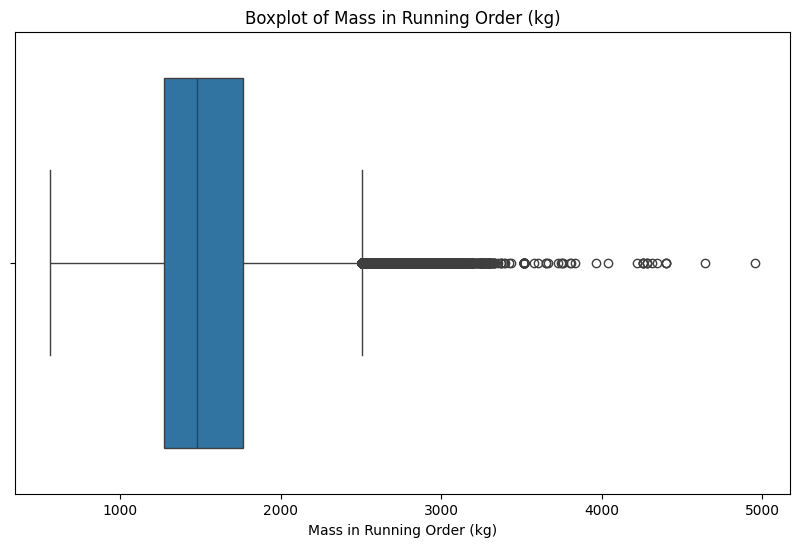

In [235]:
display(df_a['Mass_in_Running_Order(kg)'].head(20).mean())
# Checking for outliers in 'Mass_in_Running_Order(kg)' using IQR method
Q1 = df_a['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_a['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_a[(df_a['Mass_in_Running_Order(kg)'] < (Q1 - 1.5 * IQR)) | (df_a['Mass_in_Running_Order(kg)'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers in 'Mass_in_Running_Order(kg)': {len(outliers)}")
# Visualizing the distribution of 'Mass_in_Running_Order(kg)'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['Mass_in_Running_Order(kg)'])
plt.title('Boxplot of Mass in Running Order (kg)')
plt.xlabel('Mass in Running Order (kg)')    

Number of outliers in 'WLTP_test_mass': 165900


Text(0.5, 1.0, 'Boxplot of WLTP Test Mass')

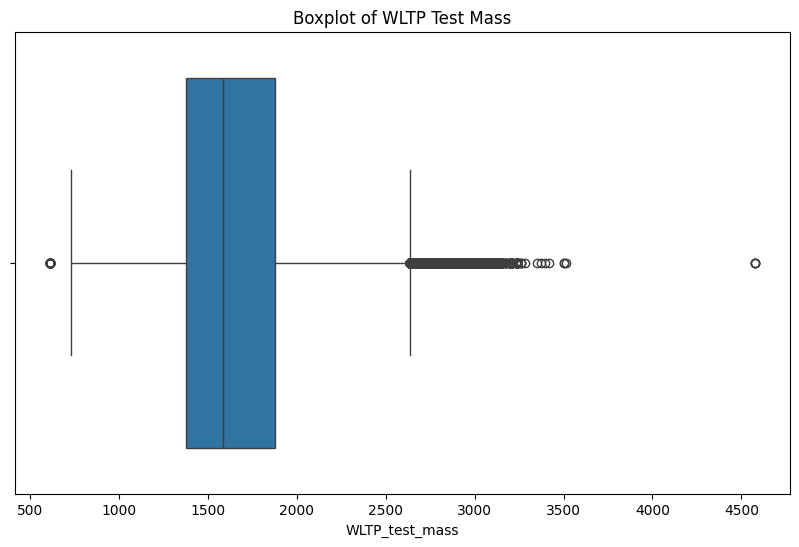

In [236]:
df_a['WLTP_test_mass'].describe()
# Checking for outliers in 'WLTP_test_mass' using IQR method
Q1_wltp = df_a['WLTP_test_mass'].quantile(0.25)
Q3_wltp = df_a['WLTP_test_mass'].quantile(0.75)
IQR_wltp = Q3_wltp - Q1_wltp
outliers_wltp = df_a[(df_a['WLTP_test_mass'] < (Q1_wltp - 1.5 * IQR_wltp)) | (df_a['WLTP_test_mass'] > (Q3_wltp + 1.5 * IQR_wltp))]
print(f"Number of outliers in 'WLTP_test_mass': {len(outliers_wltp)}") 
# Visualizing the distribution of 'WLTP_test_mass'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['WLTP_test_mass'])
plt.title('Boxplot of WLTP Test Mass')              

## End of mass

## categorical variables exploration

In [237]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2754276 (25.7%)
    FR: 1889599 (17.6%)
    IT: 1563057 (14.6%)
    ES: 974227 (9.1%)
    BE: 475470 (4.4%)
    PL: 474293 (4.4%)
    NL: 364750 (3.4%)
    SE: 294410 (2.7%)
    AT: 238542 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 8637
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 191789 (1.9%)
    IP-0153-JT1-1: 118953 (1.2%)
    IP-0110-JT1-1: 94937 (0.9%)
    IP-JAA1MTPJT4A_000-VF1-1: 82074 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69012 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 62615 (0.6%)
    IP-HMR____MA5_131

### General Overview of Categorical Variables


- The most of the variable should be interpreted properly. We don't know how to interpret the values in the following categorical variables: 
    - Vehicle_Family_id_number
    - Type_approval_number
    - Type
    - Variant
    - Version
    - Category_type_approved
    - Fuel_Mode
    - Innovative_Technologies
    - Electric_Charge
    - RLFI



## TARGET VARIABLE ANALYSIS: CO2 (g/km)

In [238]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_a['CO2_Emissions_WLTP(g/km)'].describe())

count   10713765.0
mean         106.7
std           59.6
min            0.0
25%          101.0
50%          123.0
75%          139.0
max          543.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

C:\Users\Tavo\AppData\Local\Temp\ipykernel_11140\3635154306.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Tavo\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


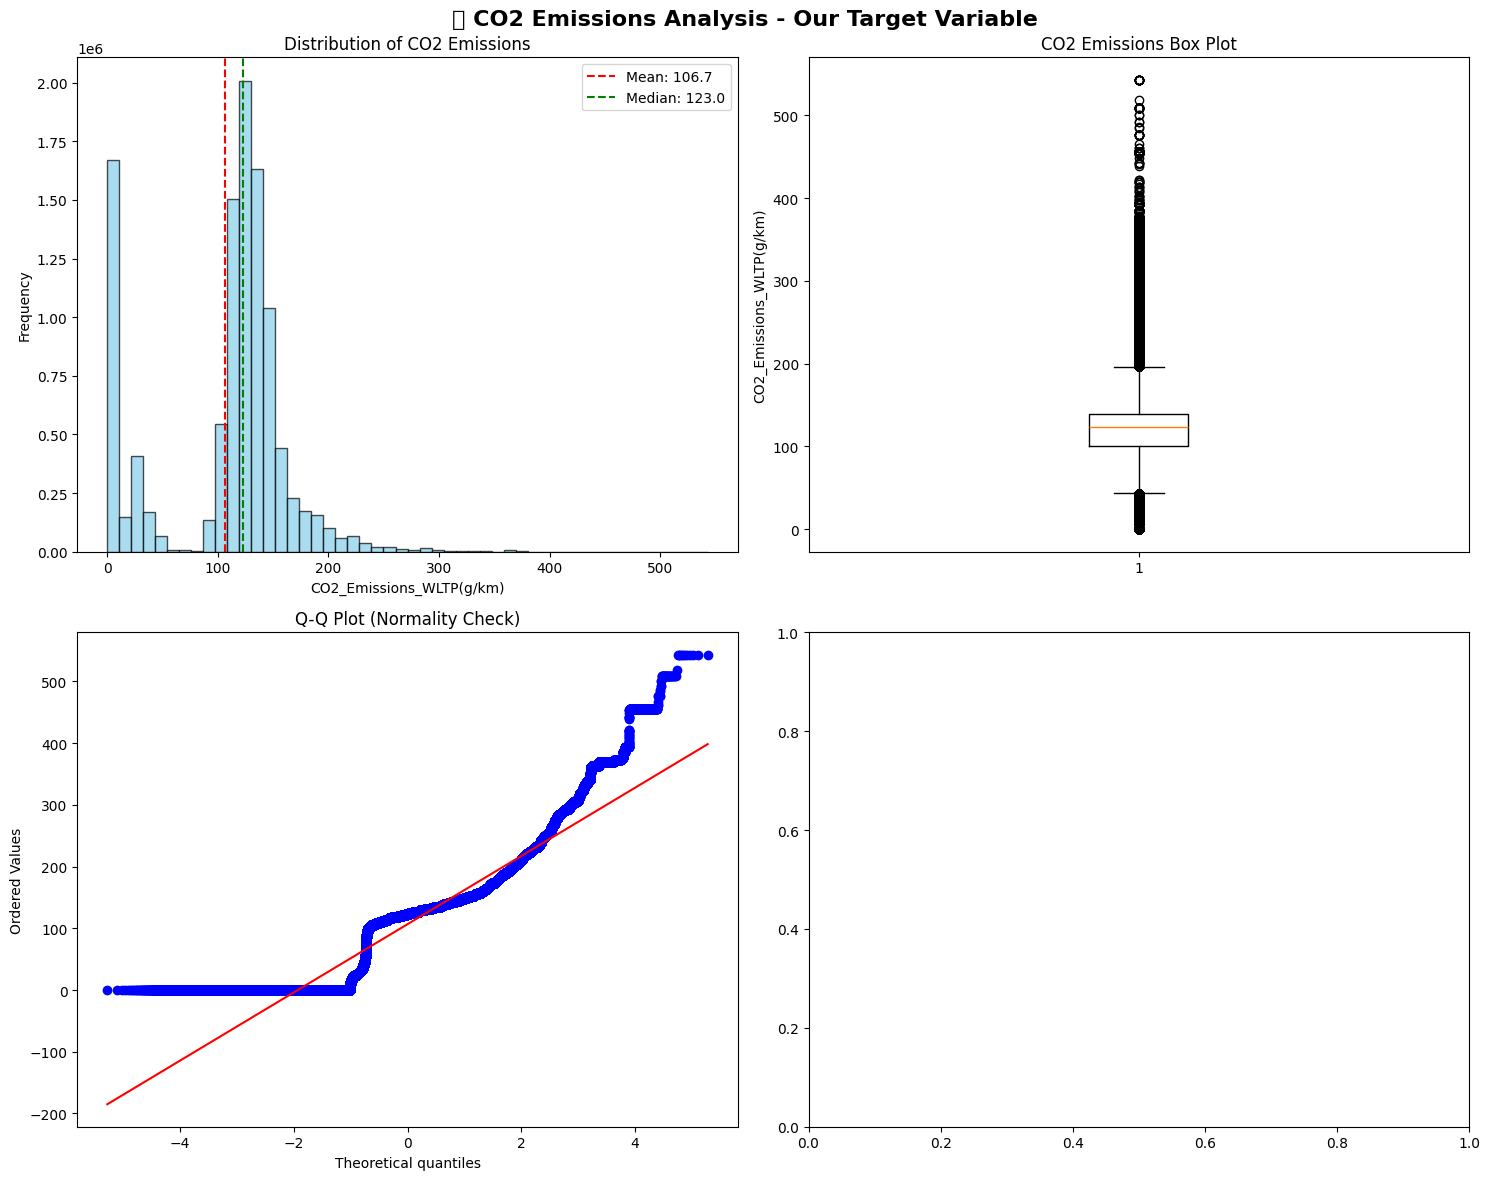

In [239]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()


The 0 and close to 0 CO2 emission values are most probably the electric cars. They should be investigated properly to understand what is the feature that distinguish them

In [240]:
# Displaying the features of CO2 Emissions free rows
df_a_CO2free = df_a[df_a['CO2_Emissions_WLTP(g/km)'] == 0]

display(df_a_CO2free['Fuel_Type'].value_counts())
display(df_a_CO2free['Fuel_Mode'].value_counts())


Fuel_Type
electric    1669450
hydrogen        730
Name: count, dtype: int64

Fuel_Mode
E    1669450
M        729
B          1
Name: count, dtype: int64

In [241]:
# Displaying the rows that have less than 50 g/km CO2 emissions
low_50_co2 = df_a[(df_a['CO2_Emissions_WLTP(g/km)'] < 50) & (df_a['CO2_Emissions_WLTP(g/km)'] > 0)]
print(f"Number of vehicles with CO2 emissions less than 50 g/km but not O: {len(low_50_co2)}")
# Displaying the rows with CO2 emissions less than 50 g/km
display(low_50_co2.head(5))

display(low_50_co2['Fuel_Type'].value_counts())

Number of vehicles with CO2 emissions less than 50 g/km but not O: 783013


,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel_consumption,Electric_Charge,RLFI,Electric range (km)
8,130815562,DE,IP-041225-U5Y-1,KIA,KIA SLOVAKIA,KIA SLOVAKIA SRO,e4*2007/46*1299*18,CD,F5P61,D61LZ1,KIA,CEED,M1,M1,1,1614.0,1750.0,33.0,petrol/electric,P,1580.0,77.0,125.0,NaN,NaN,P,2023,2023-04-27,1.5,NaN,RL-041203-U5Y-1,55.0
42,130815596,DE,IP-2021_3403-W1K-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,e1*2007/46*1560*33,R1ES,U21IT1,CZAA050E,MERCEDES-BENZ,E 300 DE 4MATIC,M1,M1,1,2215.0,2382.0,38.0,diesel/electric,P,1950.0,143.0,165.0,NaN,NaN,P,2023,2023-08-04,1.5,NaN,RL-2017_0220-WDB-1,47.0
79,130815633,DE,IP-MQB37AZ_B1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*68,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSB0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,2035.0,36.0,petrol/electric,P,1395.0,110.0,175.0,NaN,NaN,P,2023,2023-07-26,1.6,NaN,RL-DQ400E6F_20_001-WVW-1,52.0
82,130815636,DE,IP-MQB37AZ_A1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*67,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSA0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,1985.0,35.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-03-01,1.5,NaN,RL-DQ400E6F_20_001-WVW-1,53.0
106,130815660,DE,IP-VN41TZZ_A4_0474-WVN-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2018/858*00018*08,ST,MDGEAX0,MNFD6FD6DD00217T4BI1A700A,VOLKSWAGEN VW,MULTIVAN,M1,M1,1,2194.0,2382.0,42.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-10-11,1.9,NaN,RL-DQ400E6F_20_701-WVN-1,47.0


Fuel_Type
petrol/electric    757754
diesel/electric     25239
petrol                 19
diesel                  1
Name: count, dtype: int64

As the extreme values are legit, we cannot remove them from the dataset

## FILTERING DATASET - Petrol & Diesel

In [242]:
# Filtering the DataFrame to include only petrol and diesel vehicles
df_a = df_a[df_a['Fuel_Type'].isin(['petrol', 'diesel'])]

# Displaying the shape of the DataFrame after filtering
df_a.shape

(7870432, 32)

In [243]:
df_a['Fuel_Type'].value_counts()

Fuel_Type
petrol    6049317
diesel    1821115
Name: count, dtype: int64

## TARGET VARIABLE ANALYSIS v2: CO2 (g/km) - after filtering

In [244]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_a['CO2_Emissions_WLTP(g/km)'].describe())

count   7870432.0
mean        136.4
std          29.5
min           1.0
25%         119.0
50%         131.0
75%         145.0
max         543.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

C:\Users\Tavo\AppData\Local\Temp\ipykernel_11140\3611984606.py:25: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\Tavo\Documents\GitHub\DataScientest-may25_bds_co2\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


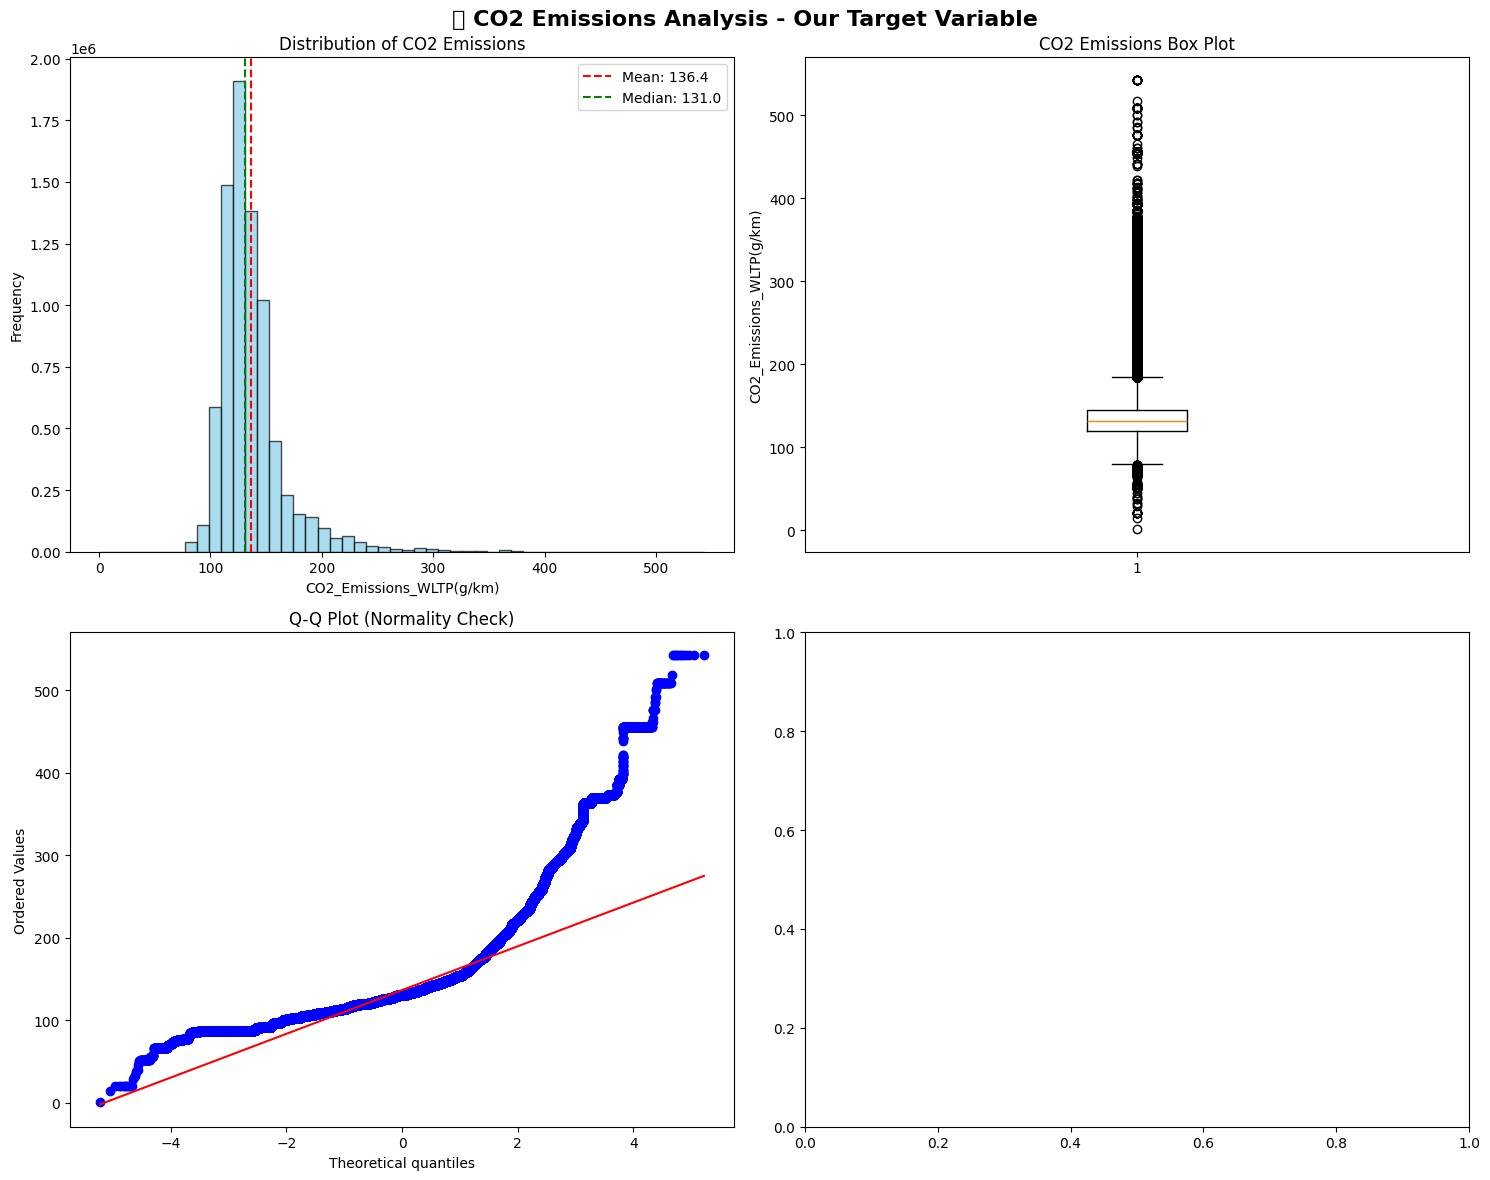

In [245]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')



plt.tight_layout()
plt.show()

Q-Q PLOT: The data follows almost a normal distribution so it is approximately(?) normal enough for most statistical analyses.

In [246]:
df_a.shape

(7870432, 32)

## Applying Unique Values to find only unique auto models

In [247]:
df_unique = df_a.drop_duplicates(subset=['Commercial_Name', 'Version', 'Variant', 'Type'])

In [248]:
df_unique.shape

(55027, 32)

In [249]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column      Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID          int64           55027           0              0.0
                                    Country         object           55027           0              0.0
                   Vehicle_Family_id_number         object           49646        5381              0.1
                       Manufacturer_Pooling         object           50002        5025              0.1
                          Manufacturer_Name         object           55027           0              0.0
                      Manufacturer_name_OEM         object           55027           0              0.0
                       Type_approval_number         object           54088         939              0.0
                                       Type         object           54806         221              0.0
                                    Variant         object      

Drop columns: <br>
Vehicle_Family_id_number - the model of the car is already described by other variables <br>
Manufacturer_Pooling - the model of the car is already described by other variables <br>
Manufacturer_Name - the model of the car is already described by other variables <br>
Manufacturer_name_OEM - the model of the car is already described by other variables <br>
Manufacturer_name_MS - the model of the car is already described by other variables <br>
Type_approval_number - the model of the car is already described by other variables <br>
Type - stay <br>
Variant - stay <br>
Version - stay <br>
Make - not relevant for CO2 <br>
Commercial_Name - stay <br>
Category_type_approved - not relevant for CO2 <br>
Category_type_registered - not relevant for CO2 <br>
Total_new_registrations - not relevant for CO2 <br>
Mass_in_Running_Order(kg) - stay <br>
WLTP_test_mass - stay <br>
CO2_Emissions_NEDC(g/km) - the whole is zeros <br>
CO2_Emissions_WLTP(g/km) - our target <br>
Wheelbase(mm) - the whole is zeros <br>
Axle_Track_1(mm) - the whole is zeros <br>
Axle_Track_2(mm) - the whole is zeros<br>
Fuel_Type - stay<br>
Fuel_Mode - stay<br>
Engine_Capacity(cm3) - stay<br>
Engine_Power(kW) - stay<br>
Electric_Energy_Consumption(Wh/km) - not relevant for Combustion<br>
Innovative_Technologies - 35% of zeros, delete<br>
Emmission_reduction_through_innovation - 3100& of zeros, delete<br>
Emmission_reduction_through_innovation_WLTP - 39% of zeros, delete<br>
Deviation_factor - 100% of zeros, delete<br>
Verification_factor - 100% of zeros, delete<br>
Status - delete not relevant for study<br>
 year - delete not relevant for study<br>
Date of registration - delete, not relevant for study<br>
Fuel consumption - stay<br>
Electric_Charge - not relevant for Combustion<br>
RLFI - Delete, a lot of zeros
Electric range (km) - delete, not relevant for study<br>

In [251]:
columns_to_drop = ['Vehicle_ID','Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Country',
                   'Type','Variant', 'Version','Commercial_Name', 'Type_approval_number', 'Make', 'Category_type_approved', 
                   'Category_type_registered','Total_new_registrations','Fuel_Type','Electric_Energy_Consumption(Wh/km)','year',
                   'Innovative_Technologies', 'Emmission_reduction_through_innovation_WLTP',
                   'Status','Date of registration','Electric_Charge','RLFI', 'Electric range (km)' ]

df_unique = df_unique.drop(columns_to_drop, axis=1)

In [252]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           54989          38              0.1
           WLTP_test_mass   float64           50175        4852              8.8
 CO2_Emissions_WLTP(g/km)   float64           55027           0              0.0
                Fuel_Mode    object           55027           0              0.0
     Engine_Capacity(cm3)   float64           55011          16              0.0
         Engine_Power(kW)   float64           54869         158              0.3
         Fuel_consumption   float64           44777       10250             18.6


Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel_consumption                                   0.94
WLTP_test_mass                                     0.75
Mass_in_Running_Order(kg)                          0.74
Engine_Capacity(cm3)                               0.67
Engine_Power(kW)                                   0.66


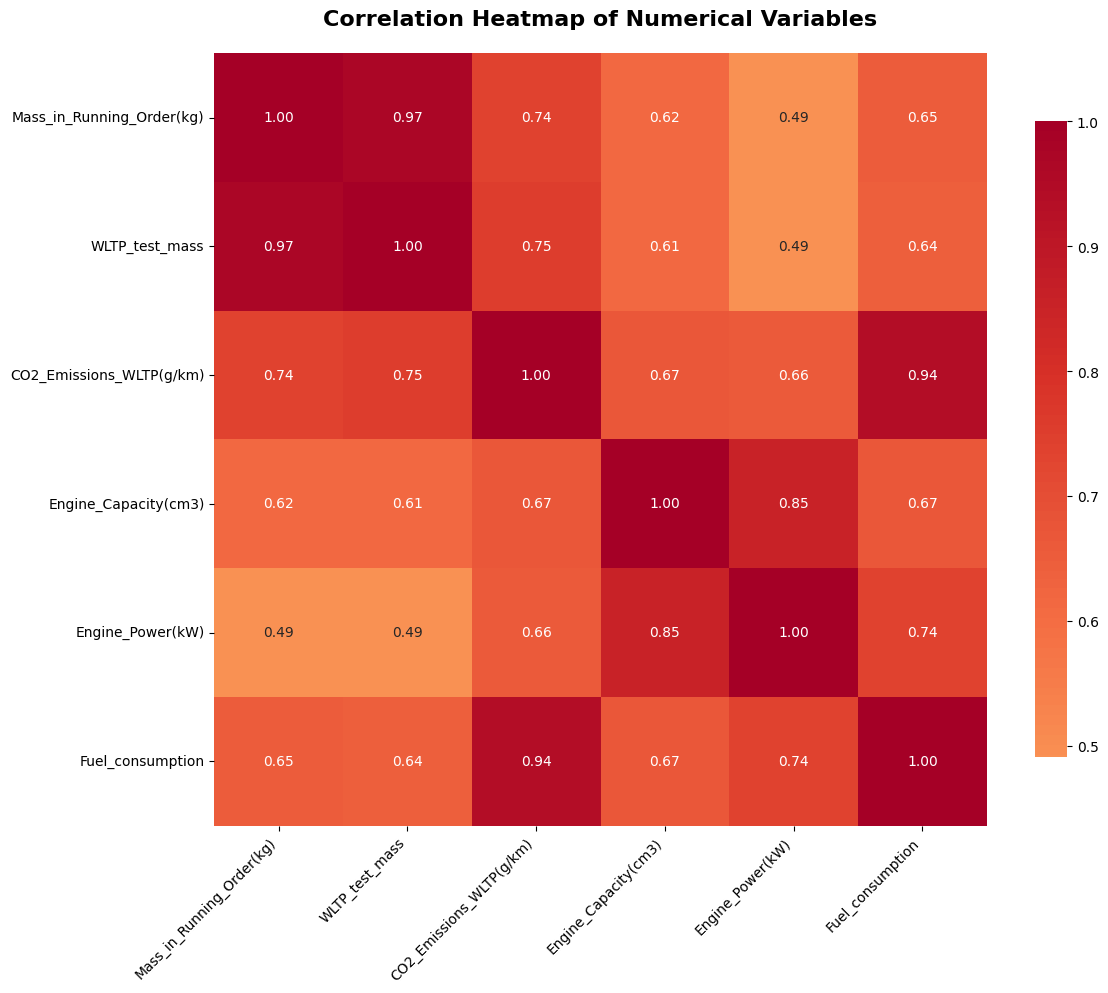

In [253]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_unique.select_dtypes(include=[np.number]).columns

#display(numerical_cols)

corr_with_co2 = df_unique[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_unique[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [254]:
# Remove rows with NaN or infinite values
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled = X_scaled.replace([np.inf, -np.inf], np.nan).dropna()
vif_df = pd.DataFrame()
vif_df['Feature'] = X_scaled.columns
vif_df['VIF'] = [variance_inflation_factor(X_scaled.values, i) for i in range(X_scaled.shape[1])]
print(vif_df)

                     Feature  VIF
0  Mass_in_Running_Order(kg) 24.1
1             WLTP_test_mass 22.9
2       Engine_Capacity(cm3)  5.1
3           Engine_Power(kW)  5.6
4          Fuel consumption   3.1


serious colinearity between Mass_in_Running_Order(kg) and WLTP_test_mass, we'll delete the one with mroe zeros

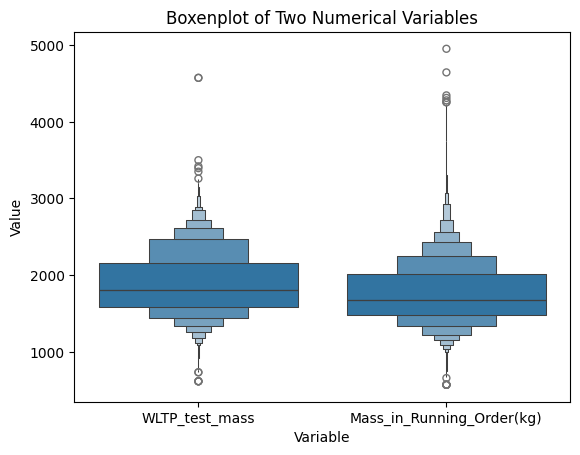

In [255]:

# Pick two numerical columns
cols = ['WLTP_test_mass', 'Mass_in_Running_Order(kg)']

# Melt the data
df_melted = df_unique[cols].melt(var_name='Variable', value_name='Value')

# Plot
sns.boxenplot(x='Variable', y='Value', data=df_melted)
plt.title('Boxenplot of Two Numerical Variables')
plt.show()

In [256]:
difference_masses = df_unique['WLTP_test_mass'].mean() - df_unique['Mass_in_Running_Order(kg)'].mean() 

In [257]:
df_unique['Mass_in_Running_Order(kg)'] = df_unique['Mass_in_Running_Order(kg)'].fillna(
    df_unique['WLTP_test_mass'] - difference_masses)

In [258]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           55009          18              0.0
           WLTP_test_mass   float64           50175        4852              8.8
 CO2_Emissions_WLTP(g/km)   float64           55027           0              0.0
                Fuel_Mode    object           55027           0              0.0
     Engine_Capacity(cm3)   float64           55011          16              0.0
         Engine_Power(kW)   float64           54869         158              0.3
         Fuel_consumption   float64           44777       10250             18.6


still some NA in Mass_in_Running_Order(kg), lets drop na values

In [259]:
df_unique=  df_unique.dropna(subset=['Mass_in_Running_Order(kg)'])

In [260]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           55009           0              0.0
           WLTP_test_mass   float64           50175        4834              8.8
 CO2_Emissions_WLTP(g/km)   float64           55009           0              0.0
                Fuel_Mode    object           55009           0              0.0
     Engine_Capacity(cm3)   float64           54995          14              0.0
         Engine_Power(kW)   float64           54854         155              0.3
         Fuel_consumption   float64           44767       10242             18.6


now we drop the WLTP_test_mass

In [261]:

df_unique = df_unique.drop('WLTP_test_mass', axis=1)

In [262]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           55009           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           55009           0              0.0
                Fuel_Mode    object           55009           0              0.0
     Engine_Capacity(cm3)   float64           54995          14              0.0
         Engine_Power(kW)   float64           54854         155              0.3
         Fuel_consumption   float64           44767       10242             18.6


In [263]:
df_unique=  df_unique.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

In [264]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           55009           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           55009           0              0.0
                Fuel_Mode    object           55009           0              0.0
     Engine_Capacity(cm3)   float64           54995          14              0.0
         Engine_Power(kW)   float64           54854         155              0.3
         Fuel_consumption   float64           44767       10242             18.6


In [265]:
df_unique=  df_unique.dropna(subset=['Engine_Capacity(cm3)','Engine_Power(kW)','Fuel_consumption'])

In [266]:
df_info = pd.DataFrame({
    'Column': df_unique.columns,
    'Data Type': df_unique.dtypes,
    'Non-Null Count': df_unique.count(),
    'Null Count': df_unique.isnull().sum(),
    'Null Percentage': (df_unique.isnull().sum() / len(df_unique) * 100).round(2)
})
print(df_info.to_string(index=False))

                   Column Data Type  Non-Null Count  Null Count  Null Percentage
Mass_in_Running_Order(kg)   float64           44764           0              0.0
 CO2_Emissions_WLTP(g/km)   float64           44764           0              0.0
                Fuel_Mode    object           44764           0              0.0
     Engine_Capacity(cm3)   float64           44764           0              0.0
         Engine_Power(kW)   float64           44764           0              0.0
         Fuel_consumption   float64           44764           0              0.0


Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)    1.0
Fuel_consumption            0.9
Mass_in_Running_Order(kg)   0.8
Engine_Power(kW)            0.7
Engine_Capacity(cm3)        0.7
Name: CO2_Emissions_WLTP(g/km), dtype: float64


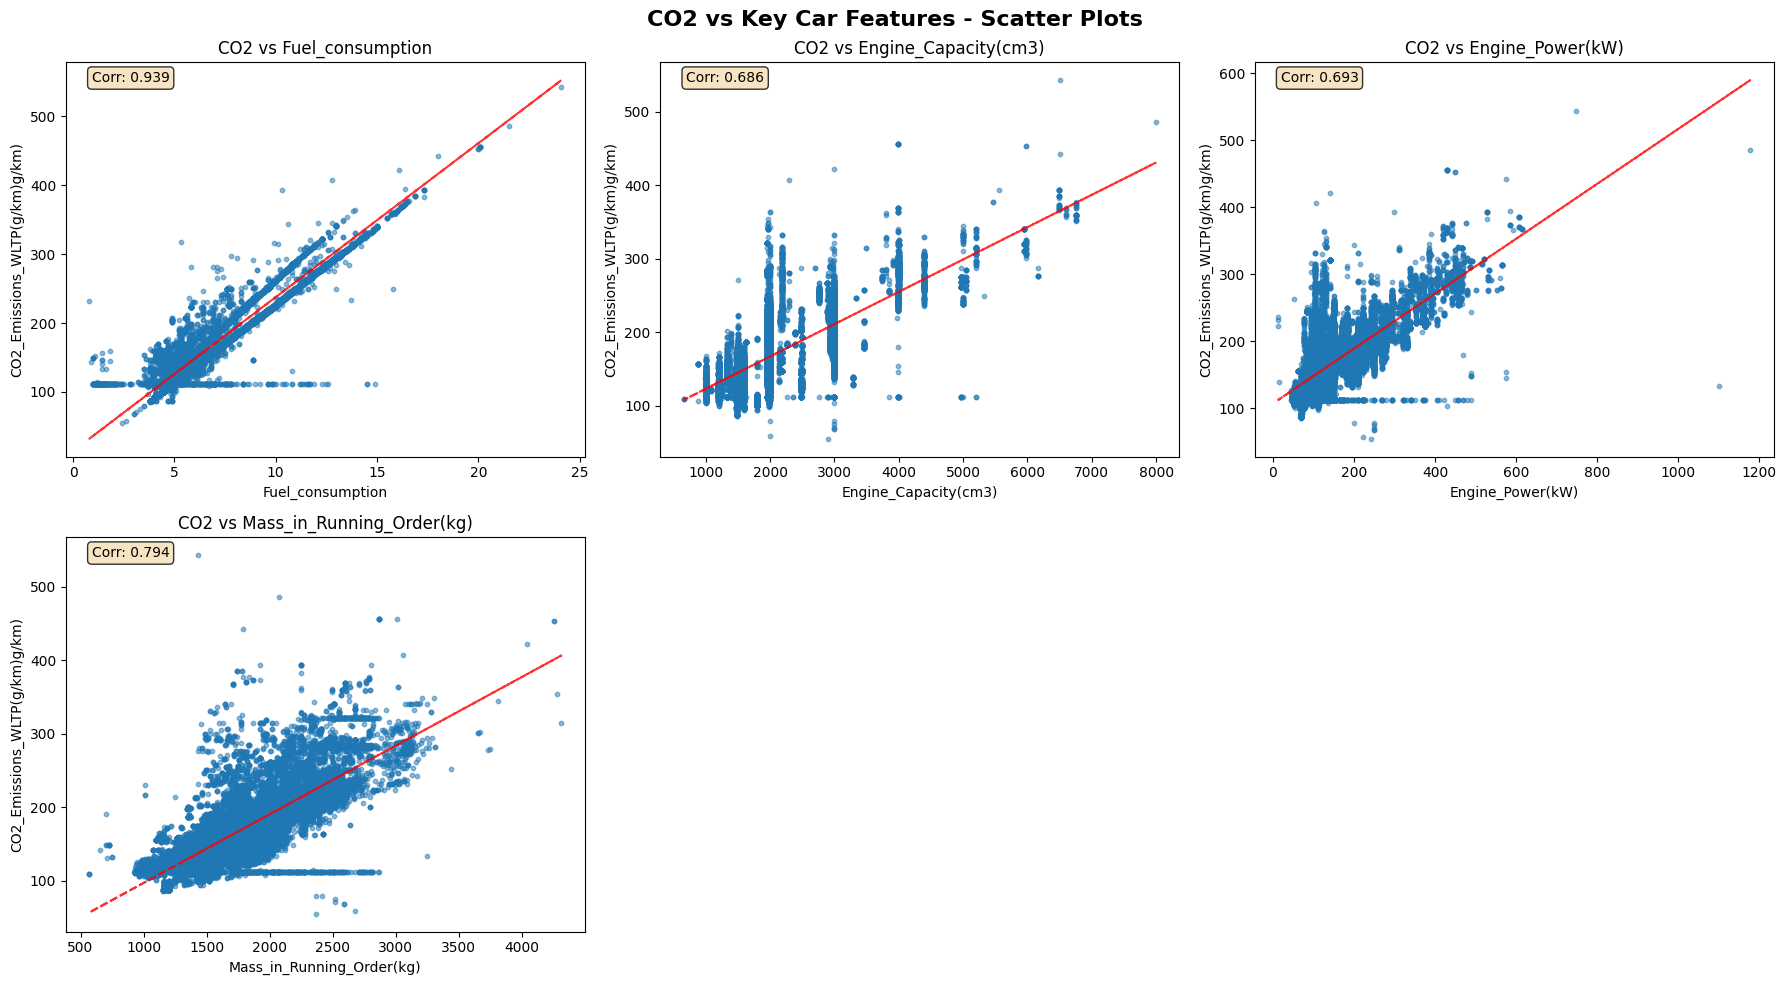

In [267]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fuel_consumption',
                 'Engine_Capacity(cm3)',
                 'Engine_Power(kW)',
                 'Mass_in_Running_Order(kg)']


numerical_cols = df_unique.select_dtypes(include=[np.number]).columns
corr_with_co2 = df_unique[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df_unique.columns:
        clean_data = df_unique[[feature, 'CO2_Emissions_WLTP(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2_Emissions_WLTP(g/km)g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2_Emissions_WLTP(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Does Fuel Consumption  has a relationship with CO2 Emmissions

- Null Hypothesis (H₀): There is no linear relationship between fuel consumoption and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between fuel consumoption and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== FUEL CONSUMPTION AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Pearson Correlation Coefficient: 0.938734
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.918883
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Very Strong positive linear relationship
Spearman: Very Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.881222
   Interpretation: 88.12% of variance in CO2 emissions is explained by Fuel Consumption


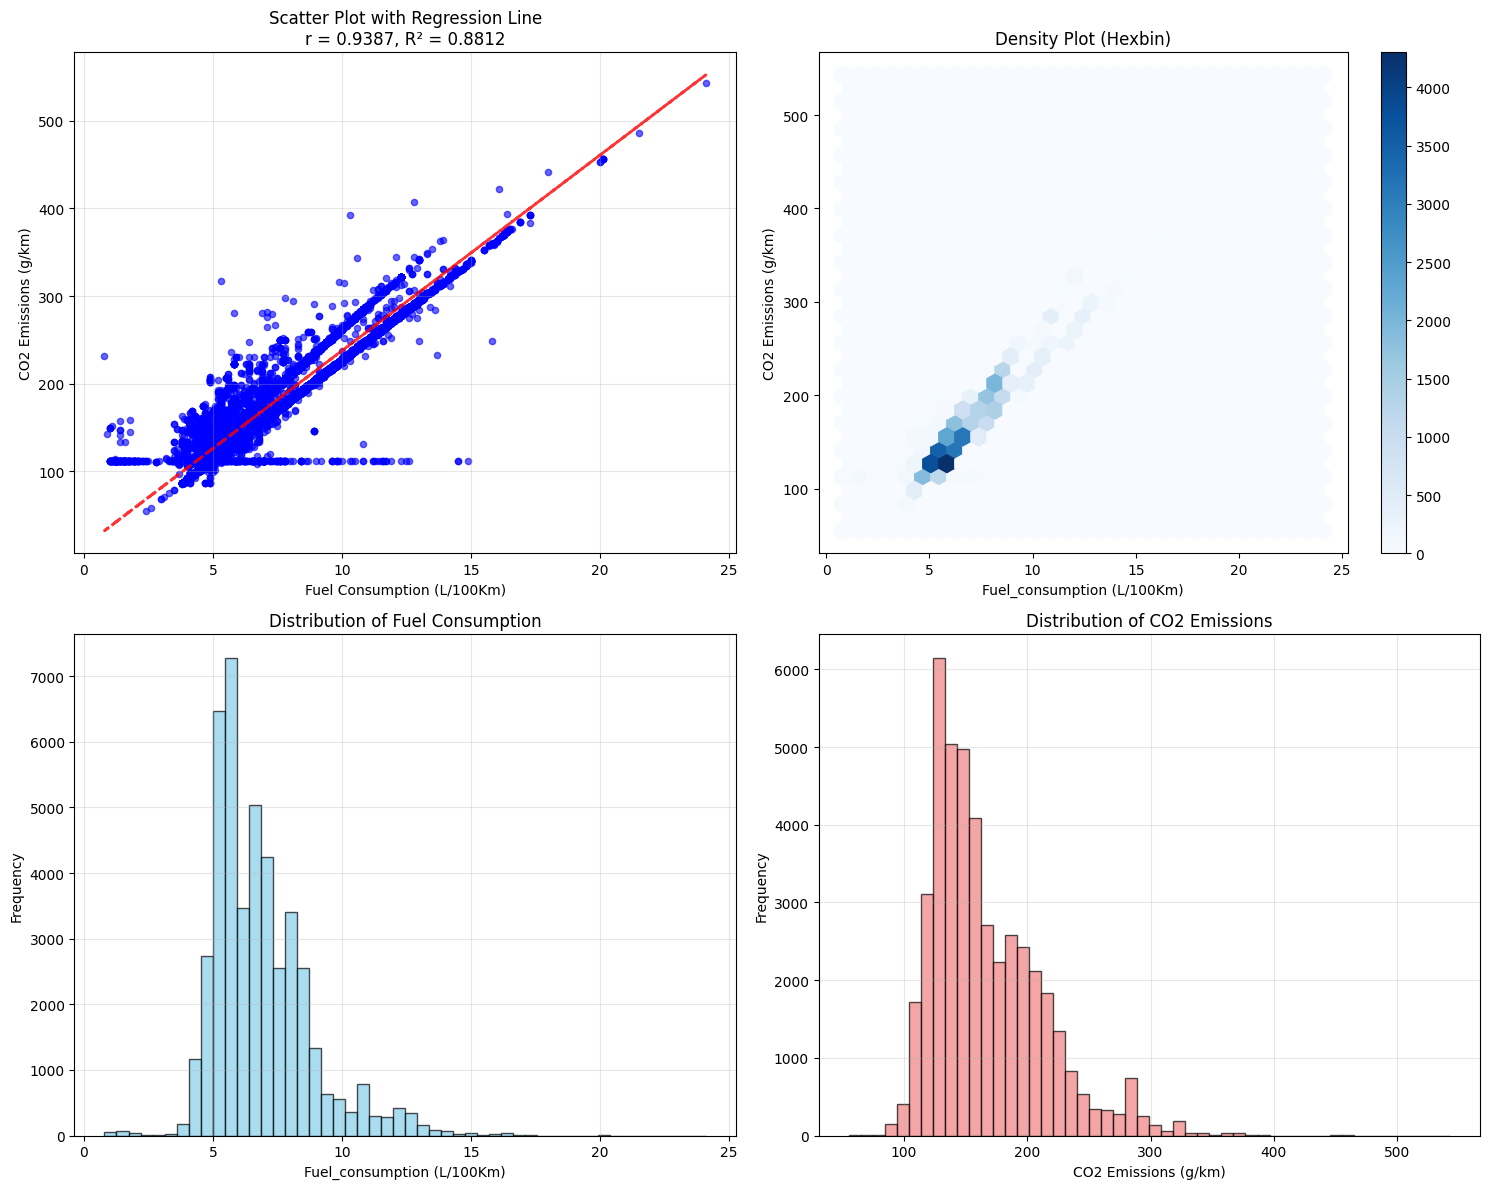


=== CONCLUSION ===
There IS a statistically significant linear relationship between Fuel Consumption and CO2 emissions.
The correlation is very strong and positive.
Engine capacity explains 88.12% of the variance in CO2 emissions.
As Fuel Consumption  increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.9189) is much different from Pearson correlation (0.9387),
this suggests a non-linear monotonic relationship might exist.


In [281]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== FUEL CONSUMPTION AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Fuel_consumption'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Fuel_consumption'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by Fuel Consumption")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Fuel_consumption'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Fuel_consumption'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Fuel_consumption'], p(df_unique['Fuel_consumption']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Fuel Consumption (L/100Km)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Fuel_consumption'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Fuel_consumption (L/100Km)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Fuel_consumption'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Fuel_consumption (L/100Km)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Fuel Consumption')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between Fuel Consumption and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As Fuel Consumption  increases, CO2 emissions tend to increase.")
    else:
        print("As Fuel Consumption  increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between Fuel Consumption and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does Engine Capacity has a relationship with CO2 Emmissions

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.685650
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.580217
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.470116
   Interpretation: 47.01% of variance in CO2 emissions is explained by engine capacity


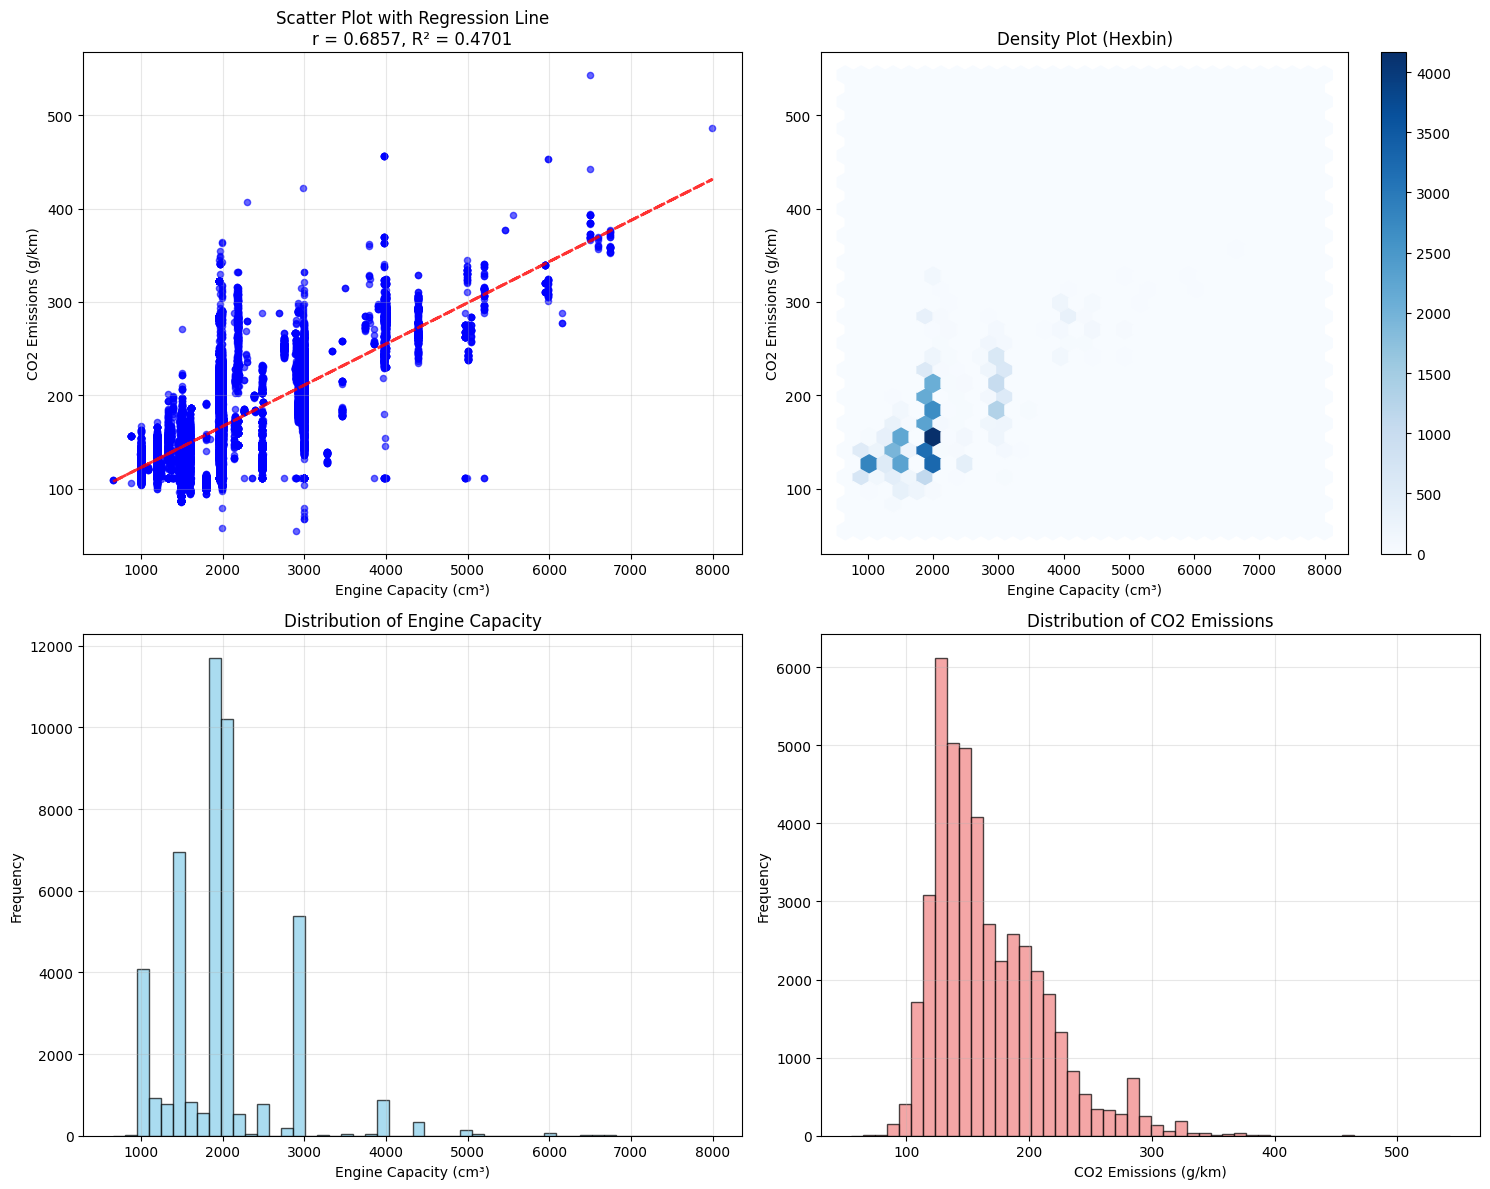


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 47.01% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.5802) is much different from Pearson correlation (0.6857),
this suggests a non-linear monotonic relationship might exist.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Capacity(cm3)'], p(df_unique['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Capacity(cm3)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does Engine Power have a relationship with Engine Power

- Null Hypothesis (H₀): There is no linear relationship between fuel consumoption and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between fuel consumoption and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.693207
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.690650
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.480535
   Interpretation: 48.05% of variance in CO2 emissions is explained by engine capacity


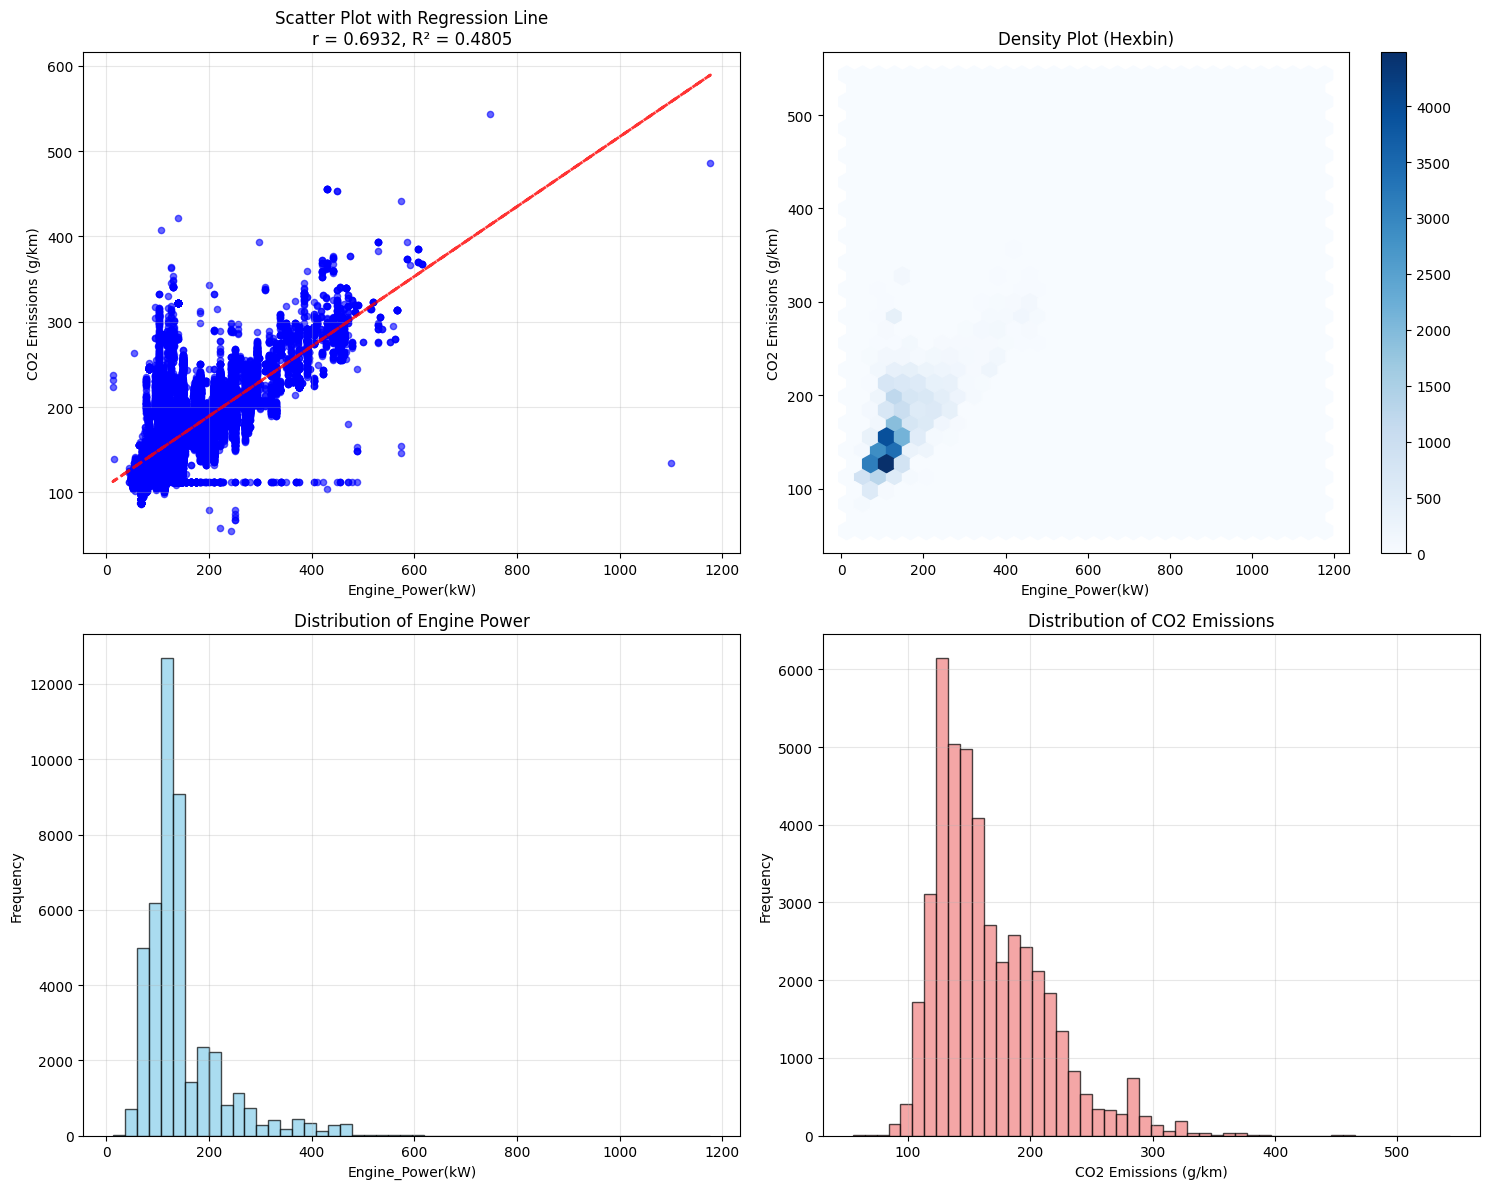


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 48.05% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.6907) is much different from Pearson correlation (0.6932),
this suggests a non-linear monotonic relationship might exist.


In [272]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE POWER AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Engine_Power(kW)'], p(df_unique['Engine_Power(kW)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine_Power(kW)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Engine_Power(kW)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine_Power(kW)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Engine_Power(kW)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine_Power(kW)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Power')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## Does Engine Power have a relationship with Mass_in_Running_Order

- Null Hypothesis (H₀): There is no linear relationship between Mass and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between Mass and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased Mass.

=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.794096
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.805562
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Very Strong positive linear relationship
Spearman: Very Strong positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.630589
   Interpretation: 63.06% of variance in CO2 emissions is explained by mass


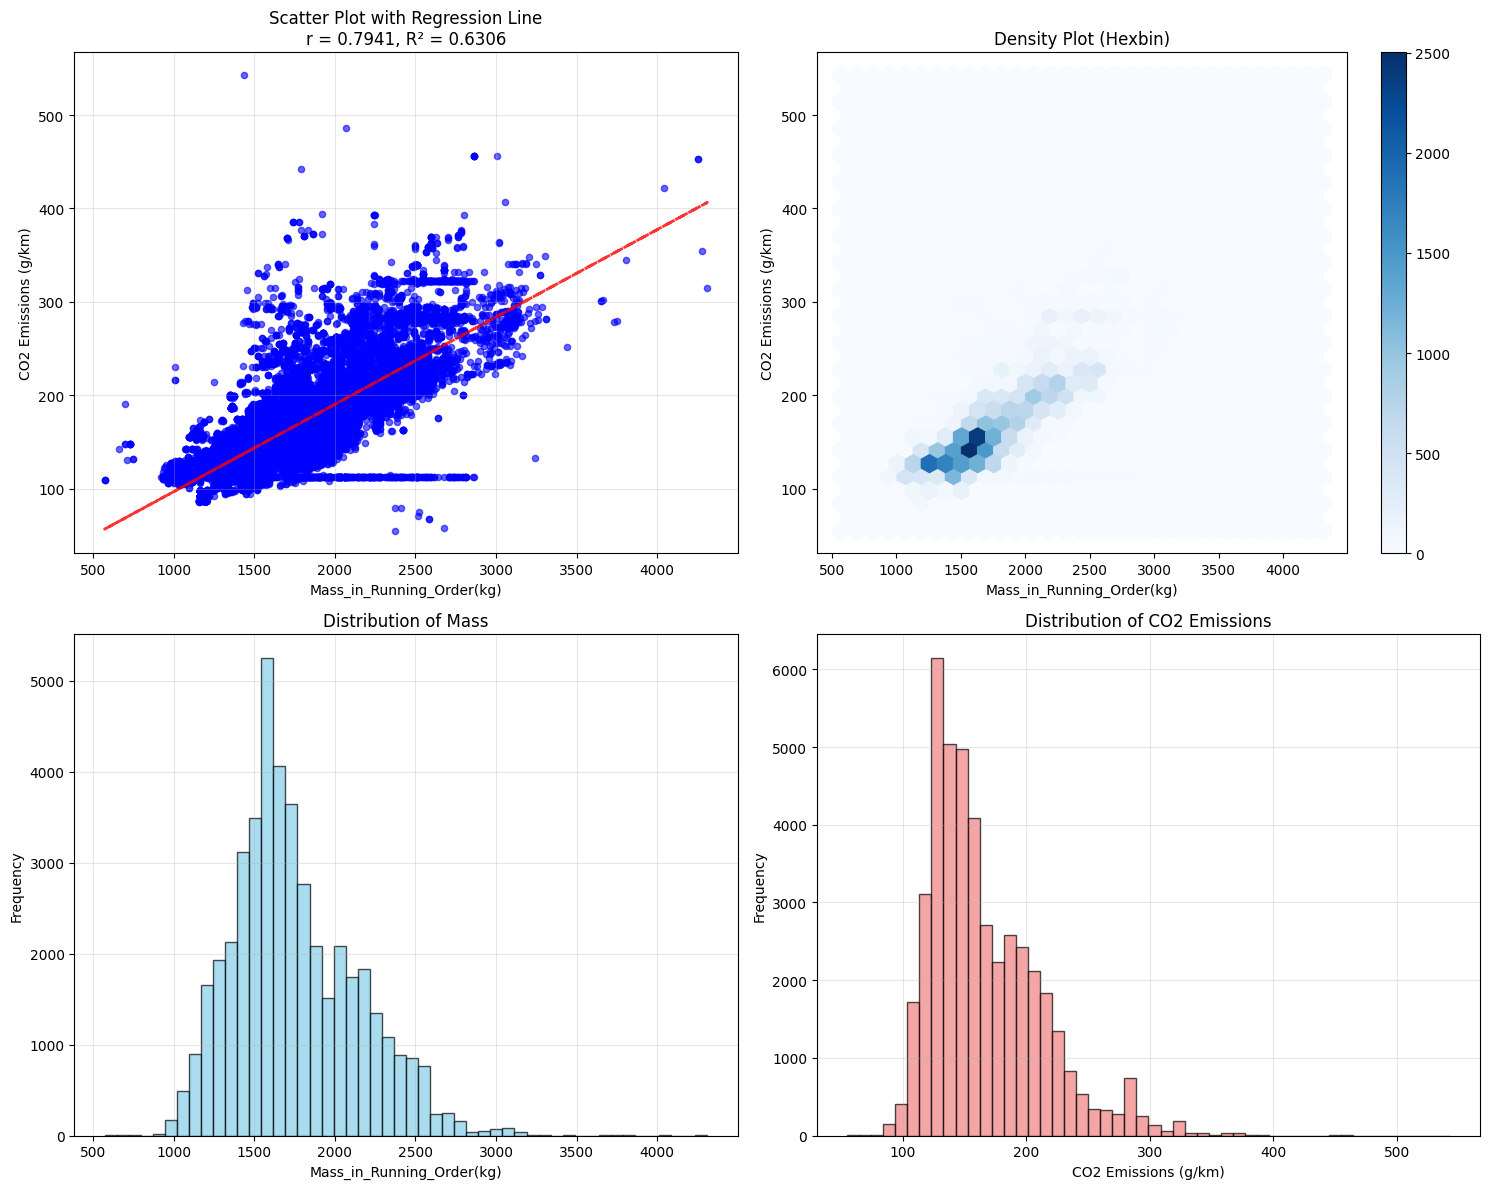


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is very strong and positive.
Engine capacity explains 63.06% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.8056) is much different from Pearson correlation (0.7941),
this suggests a non-linear monotonic relationship might exist.


In [283]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== MASS AND CO2 EMISSIONS CORRELATION ANALYSIS ===")

# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by mass")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_unique['Mass_in_Running_Order(kg)'], p(df_unique['Mass_in_Running_Order(kg)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_unique['Mass_in_Running_Order(kg)'], df_unique['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Mass_in_Running_Order(kg)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_unique['Mass_in_Running_Order(kg)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Mass_in_Running_Order(kg)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Mass')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_unique['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")

## **Correlation between variables**

### Correlation matrix

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                           1.
Fuel consumption                                   0.94
Engine_Power(kW)                                   0.80
WLTP_test_mass                                     0.73
Mass_in_Running_Order(kg)                          0.71
Engine_Capacity(cm3)                               0.65
Electric_Energy_Consumption(Wh/km)                 0.19
Electric range (km)                                0.06
Emmission_reduction_through_innovation_WLTP        0.04


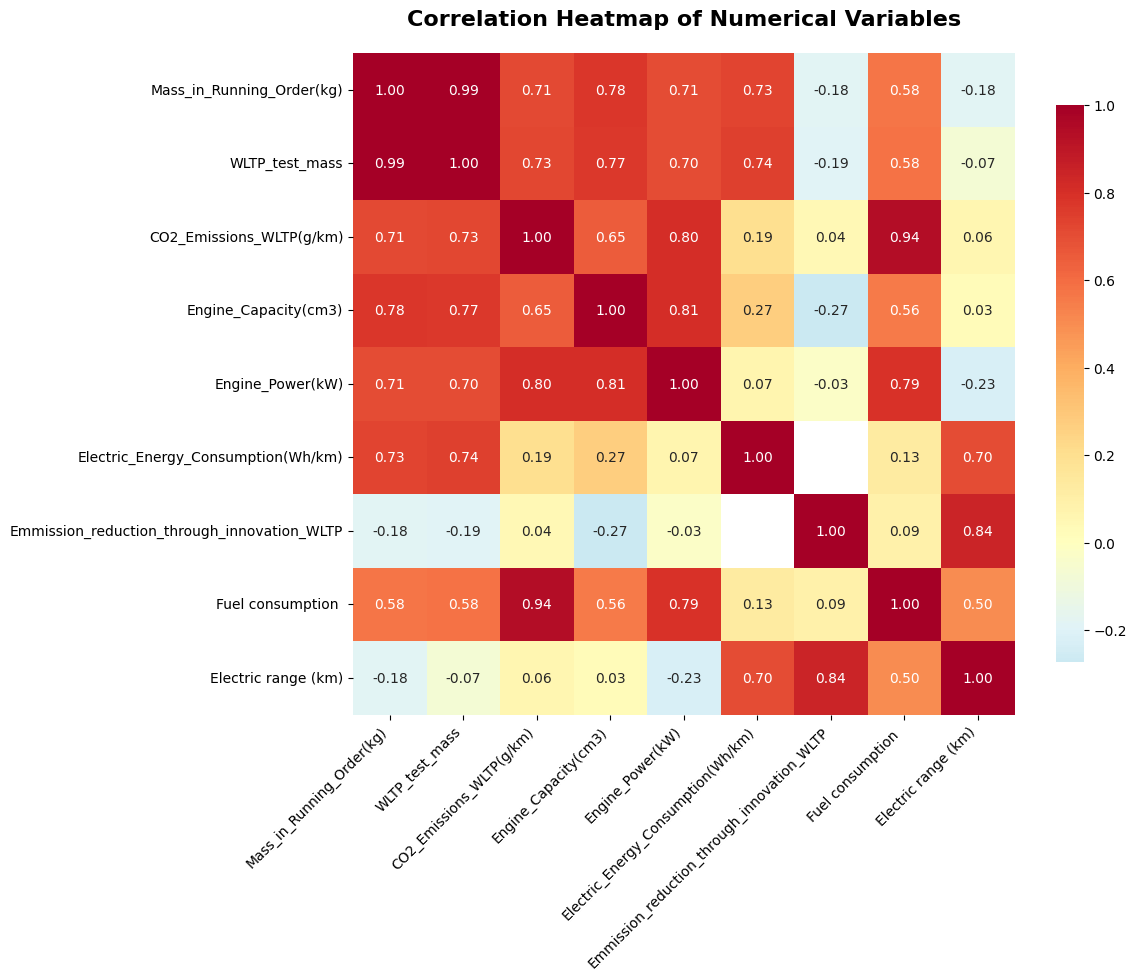

In [ ]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_a.select_dtypes(include=[np.number]).columns
columns_to_exclude = ['Total_new_registrations', 'year', 'Vehicle_ID']
numerical_cols_filtered = numerical_cols.drop(columns_to_exclude)

#display(numerical_cols)

corr_with_co2 = df_a[numerical_cols_filtered].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
for var, corr_val in corr_with_co2.items():
    print(f"{var:<50} {np.format_float_positional(corr_val, precision=2)}")


# Create correlation matrix for all numerical columns
correlation_matrix = df_a[numerical_cols_filtered].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                      1.0
Fuel consumption                              0.9
Engine_Power(kW)                              0.8
WLTP_test_mass                                0.7
Mass_in_Running_Order(kg)                     0.7
Engine_Capacity(cm3)                          0.7
Electric_Energy_Consumption(Wh/km)            0.2
Vehicle_ID                                    0.1
Electric range (km)                           0.1
Emmission_reduction_through_innovation_WLTP   0.0
Total_new_registrations                       NaN
year                                          NaN
Name: CO2_Emissions_WLTP(g/km), dtype: float64


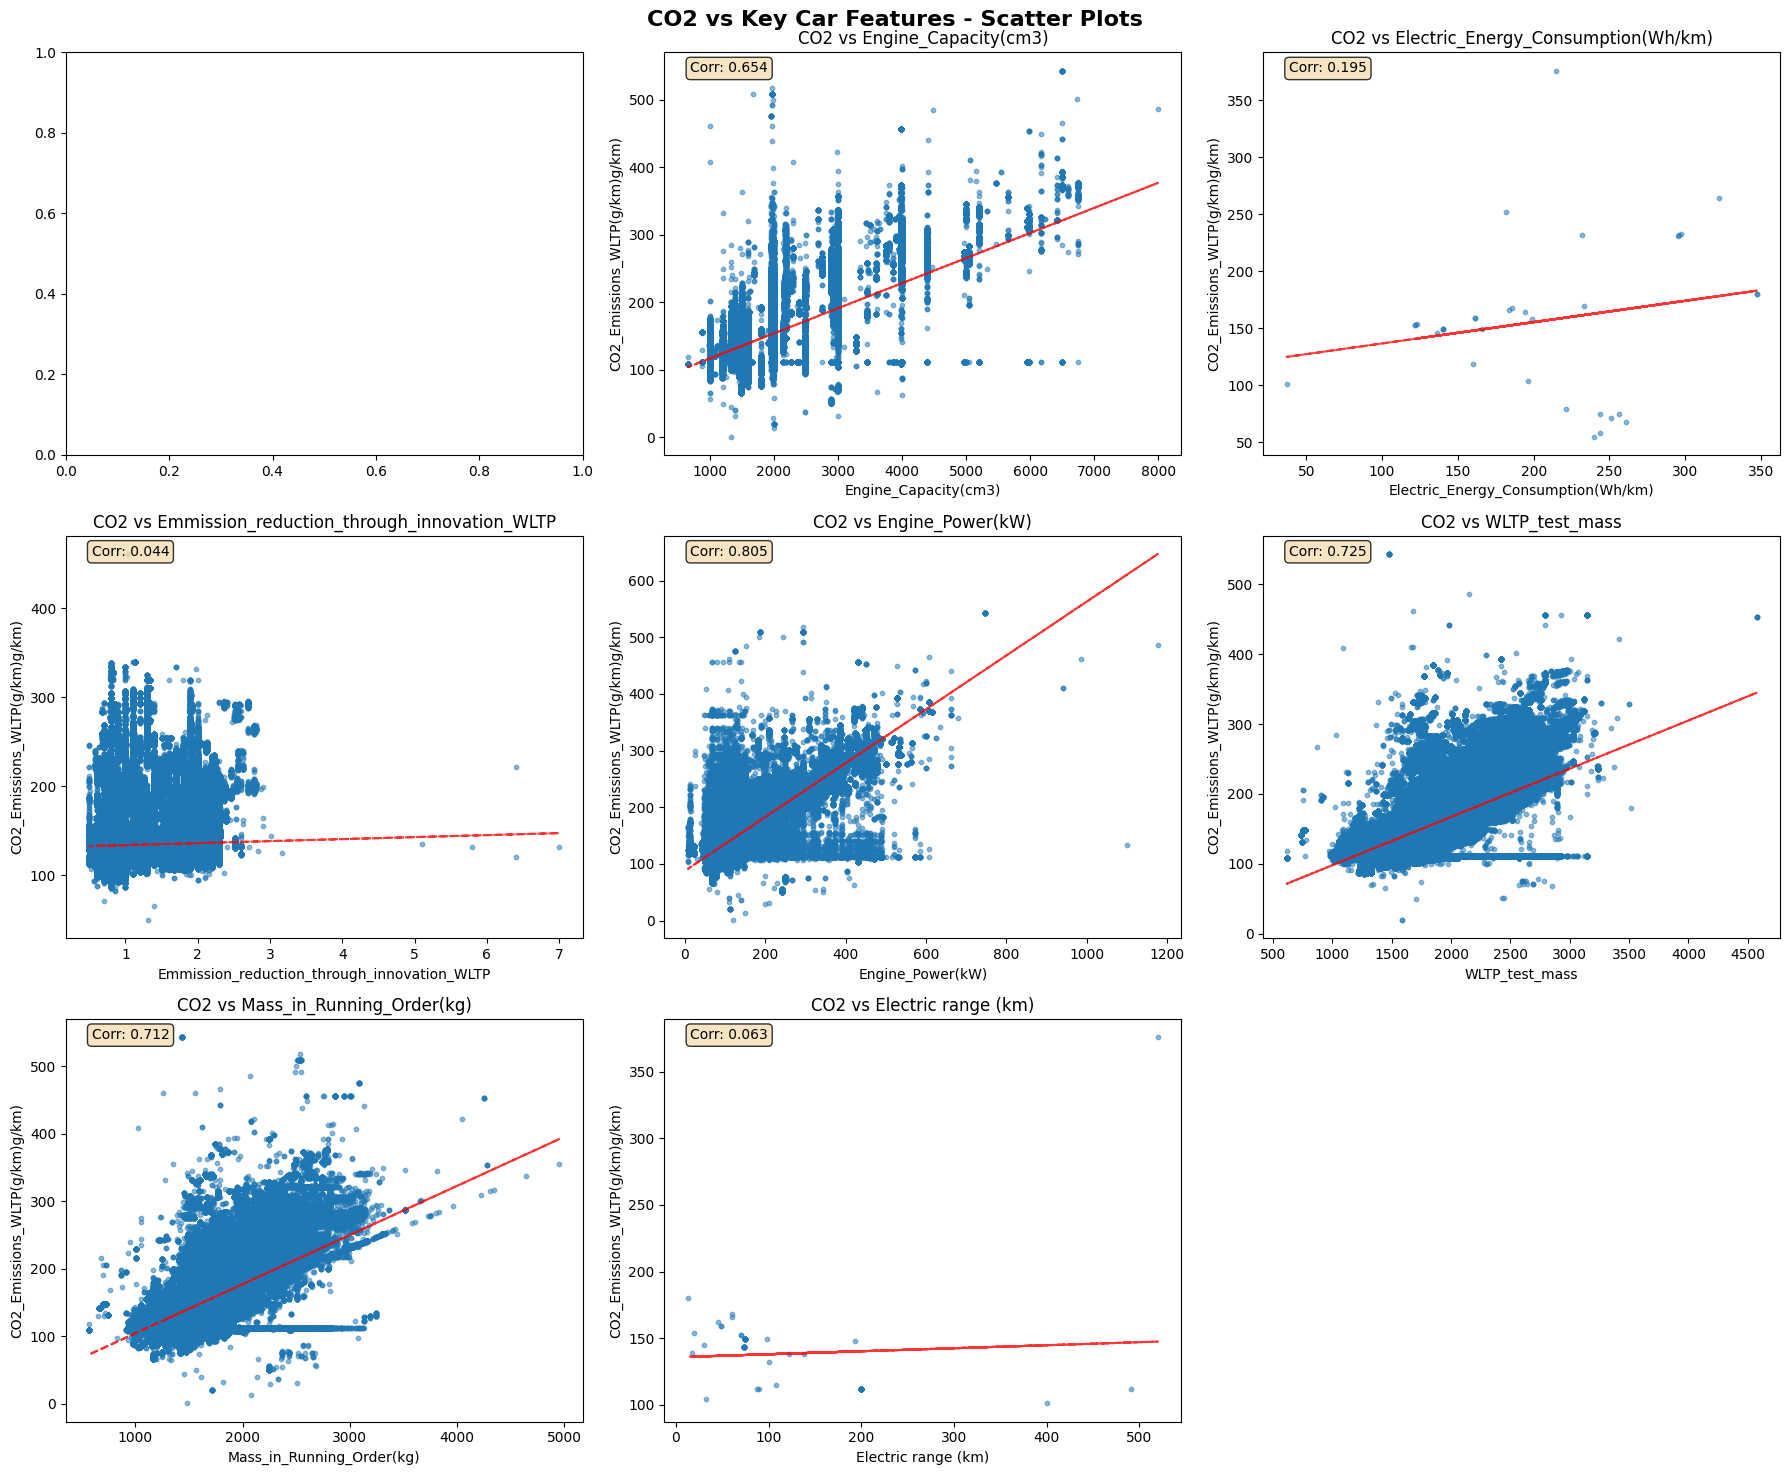

In [ ]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fuel_Consumption',
                 'Engine_Capacity(cm3)',
                 'Electric_Energy_Consumption(Wh/km)',
                 'Emmission_reduction_through_innovation_WLTP',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
                 'Electric range (km)']


numerical_cols = df_a.select_dtypes(include=[np.number]).columns
corr_with_co2 = df_a[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df_a.columns:
        clean_data = df_a[[feature, 'CO2_Emissions_WLTP(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2_Emissions_WLTP(g/km)g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2_Emissions_WLTP(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Expected strong correlations:
- Engine_Capacity(cm3): Larger engines typically produce more CO2
- Engine_Power(kW): More powerful engines usually emit more CO2
- Mass_in_Running_Order(kg): Heavier cars typically consume more fuel
- WLTP_test_mass: Similar to running mass, heavier = more emissions

### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Assuming your dataframe is called 'df'
# Select only the numerical features (exclude the target variable CO2(g/km))
features = [
                 'Fuel consumption ',
                 'Engine_Capacity(cm3)',
                 'Emmission_reduction_through_innovation_WLTP',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
]

# Create a subset with only the features
X = df_a[features]

# Handle any missing values if necessary
X = X.dropna()

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Sort by VIF values (descending)
vif_data = vif_data.sort_values('VIF', ascending=False)
print("VIF Values:")
print(vif_data)



VIF Values:
                                       Feature    VIF
5                    Mass_in_Running_Order(kg) 1762.2
4                               WLTP_test_mass 1744.2
0                            Fuel consumption    59.0
1                         Engine_Capacity(cm3)   42.8
3                             Engine_Power(kW)   21.9
2  Emmission_reduction_through_innovation_WLTP    9.7


VIF Meaning:
- VIF = 1-5:    No multicollinearity concern ✅
- VIF = 5-10:   Moderate multicollinearity ⚠️
- VIF > 10:     High multicollinearity - consider removing ❌

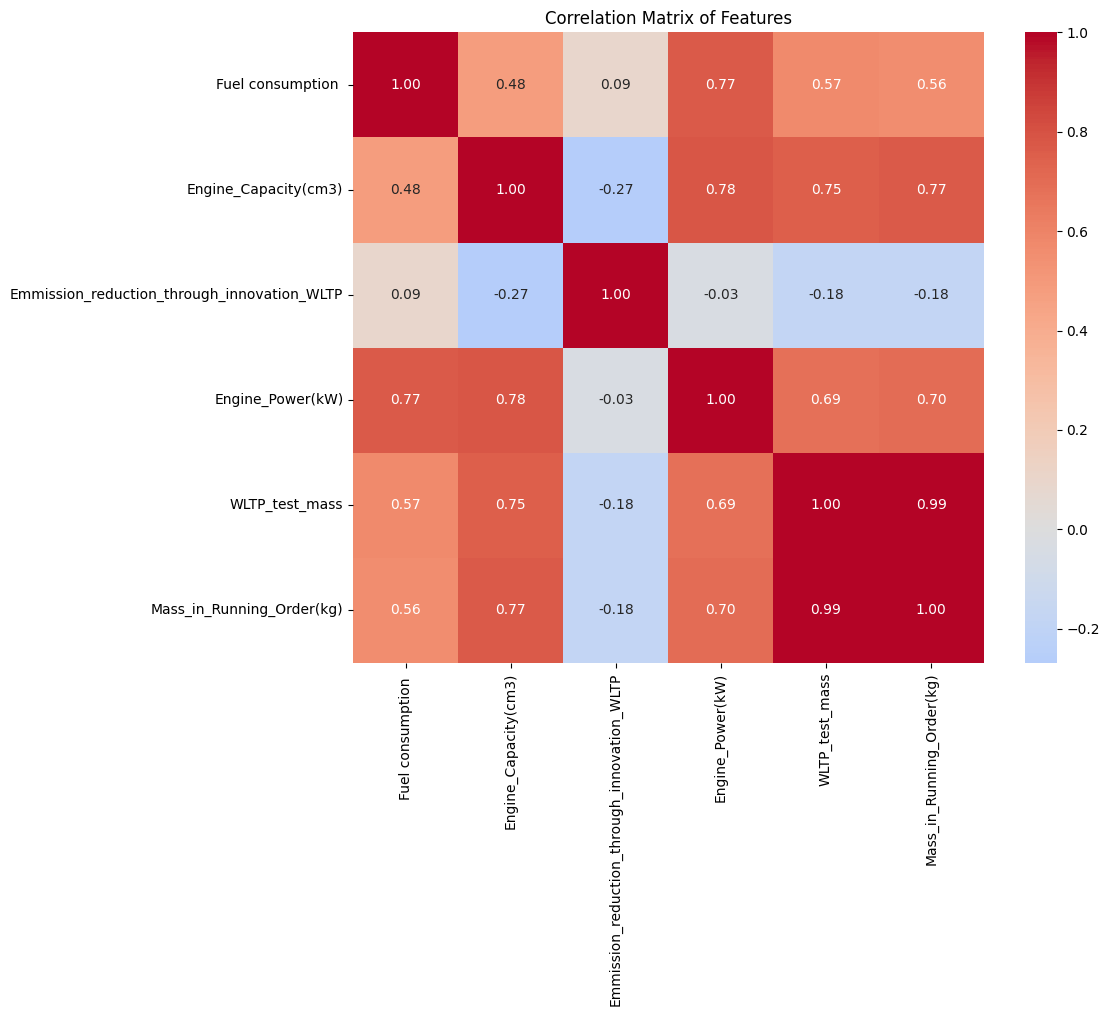


Highly correlated feature pairs (|correlation| >= 0.8):
        Feature_1                  Feature_2  Correlation
0  WLTP_test_mass  Mass_in_Running_Order(kg)          1.0


In [ ]:
# 1. Correlation matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

# 2. Identify highly correlated pairs
def find_high_correlations(corr_matrix, threshold=0.8):
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr_pairs.append({
                    'Feature_1': corr_matrix.columns[i],
                    'Feature_2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr_pairs)

high_corr_df = find_high_correlations(correlation_matrix, 0.8)
print("\nHighly correlated feature pairs (|correlation| >= 0.8):")
print(high_corr_df)

In [ ]:
recommended_features = [
    'Fuel consumption ',  
    'Engine_Capacity(cm3)',       
    'Emmission_reduction_through_innovation_WLTP',
    'Engine_Power(kW)',
    'Mass_in_Running_Order(kg)',]


# Recalculate VIF with reduced feature set
X_reduced = df_a[recommended_features]
X_reduced = X_reduced.dropna()  # Drop rows with any NaN values
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_reduced.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) 
                          for i in range(X_reduced.shape[1])]
print(vif_data_reduced.sort_values('VIF', ascending=False))

                                       Feature  VIF
4                    Mass_in_Running_Order(kg) 67.7
0                            Fuel consumption  55.8
1                         Engine_Capacity(cm3) 42.7
3                             Engine_Power(kW) 21.6
2  Emmission_reduction_through_innovation_WLTP  9.5


In [ ]:
recommended_features = [
     'Engine_Power(kW)',
    'Engine_Capacity(cm3)',       
    'Emmission_reduction_through_innovation_WLTP',
    
    ]


# Recalculate VIF with reduced feature set
X_reduced = df_a[recommended_features]
X_reduced = X_reduced.dropna()  # Drop rows with any NaN values
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_reduced.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) 
                          for i in range(X_reduced.shape[1])]
print(vif_data_reduced.sort_values('VIF', ascending=False))

                                       Feature  VIF
1                         Engine_Capacity(cm3) 17.5
0                             Engine_Power(kW) 16.1
2  Emmission_reduction_through_innovation_WLTP  4.4


In [ ]:
recommended_features = [
     'Engine_Power(kW)',       
    'Emmission_reduction_through_innovation_WLTP',
    
    ]


# Recalculate VIF with reduced feature set
X_reduced = df_a[recommended_features]
X_reduced = X_reduced.dropna()  # Drop rows with any NaN values
vif_data_reduced = pd.DataFrame()
vif_data_reduced["Feature"] = X_reduced.columns
vif_data_reduced["VIF"] = [variance_inflation_factor(X_reduced.values, i) 
                          for i in range(X_reduced.shape[1])]
print(vif_data_reduced.sort_values('VIF', ascending=False))

                                       Feature  VIF
0                             Engine_Power(kW)  4.0
1  Emmission_reduction_through_innovation_WLTP  4.0


## VFI Finished 


<span style="color:red"> Only 2 features left !!!!</span>

#### FINAL COMMENTS REGARDING VARIABLES

Potential numerical variables for the model

- Engine_Power(kW)
- Emmission_reduction_through_innovation_WLTP
- Fuel consumption (?)


Potential Categorical Variables that could be used in the model

- Country (?)
- Vehicle_Family_id_number (?)
- Type 
- Variant (?)
- Fuel_Type
- Innovative_Technologies
- RLFI (?)



### Correlation of Variables

#### Does Fuel Type has a relationship with CO2 Emmissions

#### Hypothesis
- Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different fuel types.
- Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different fuel types.
- Expected Outcome: We expect that conventional fuel types (petrol, diesel) will have higher CO2 emissions compared to alternative fuel types (electric, hybrid, hydrogen) due to their combustion-based nature.


ANOVA Test:
F-statistic: 361981.5598
P-value: 0.000000
Significance level: 0.05
Result: Reject H₀


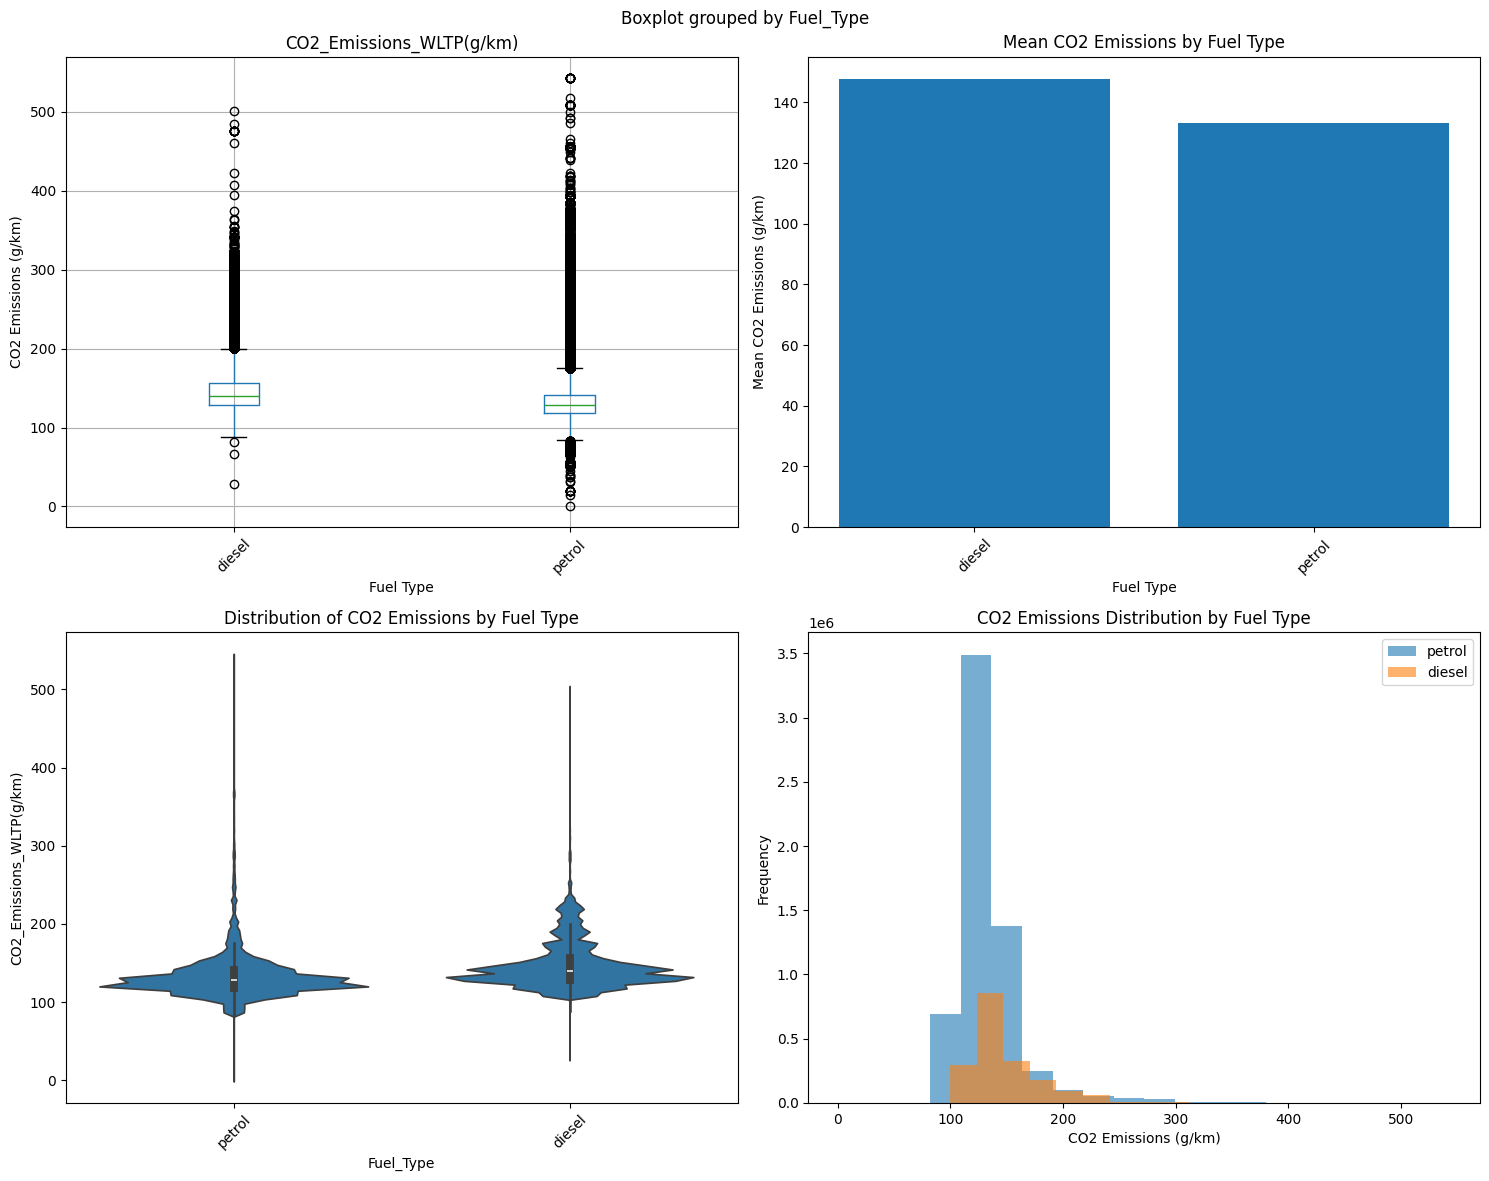


 Effect Size:
Eta-squared: 0.0440
Effect size: Medium

Post-hoc Analysis (Tukey's HSD):
Pairwise comparisons:
petrol vs diesel: p-value = 0.000000

=== CONCLUSION ===
There IS a statistically significant difference in CO2 emissions between fuel types.
This suggests that fuel type has a meaningful impact on CO2 emissions.


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# 1.Statistical Test - ANOVA
print("\nANOVA Test:")
fuel_groups = []
for fuel_type in df_a['Fuel_Type'].unique():
    if pd.notna(fuel_type):  # Exclude NaN values
        group_data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            fuel_groups.append(group_data)

# 2.Perform ANOVA
f_stat, p_value = f_oneway(*fuel_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 3. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Box plot
axes[0,0].set_title('CO2 Emissions by Fuel Type')
df_a.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Fuel_Type', ax=axes[0,0])
axes[0,0].set_xlabel('Fuel Type')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
fuel_means = df_a.groupby('Fuel_Type')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(fuel_means)), fuel_means.values)
axes[0,1].set_title('Mean CO2 Emissions by Fuel Type')
axes[0,1].set_xlabel('Fuel Type')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(fuel_means)))
axes[0,1].set_xticklabels(fuel_means.index, rotation=45)

# Violin plot
sns.violinplot(data=df_a, x='Fuel_Type', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Fuel Type')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram
for fuel_type in df_a['Fuel_Type'].unique()[:5]:  # Show top 5 fuel types
    if pd.notna(fuel_type):
        data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=fuel_type, bins=20)
axes[1,1].set_title('CO2 Emissions Distribution by Fuel Type')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 4. Effect Size (Eta-squared)
print(f"\n Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df_a['CO2_Emissions_WLTP(g/km)'].mean())**2 
                  for group in fuel_groups])
ss_total = ((df_a['CO2_Emissions_WLTP(g/km)'] - df_a['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 5. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\nPost-hoc Analysis (Tukey's HSD):")
    from scipy.stats import tukey_hsd
    
    # Prepare data for Tukey's HSD
    fuel_types = []
    co2_values = []
    for fuel_type in df_a['Fuel_Type'].unique():
        if pd.notna(fuel_type):
            fuel_data = df_a[df_a['Fuel_Type'] == fuel_type]['CO2_Emissions_WLTP(g/km)'].dropna()
            fuel_types.extend([fuel_type] * len(fuel_data))
            co2_values.extend(fuel_data.values)
    
    # Perform Tukey's HSD
    try:
        tukey_result = tukey_hsd(*fuel_groups)
        print("Pairwise comparisons:")
        for i, fuel1 in enumerate(df_a['Fuel_Type'].unique()):
            for j, fuel2 in enumerate(df_a['Fuel_Type'].unique()):
                if i < j and pd.notna(fuel1) and pd.notna(fuel2):
                    print(f"{fuel1} vs {fuel2}: p-value = {tukey_result.pvalue[i,j]:.6f}")
    except:
        print("Tukey's HSD could not be performed - using alternative pairwise tests")

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type has a meaningful impact on CO2 emissions.")
else:
    print("There is NO statistically significant difference in CO2 emissions between fuel types.")
    print("This suggests that fuel type may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Type has a relationship with CO2 Emmissions

- Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different vehicle types.
- Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different vehicle types.
- Expected: Different vehicle types (sedan, SUV, hatchback, etc.) will have different CO2 emissions due to size, weight, and aerodynamic differences.

Original dataset: 7870432 records with 1225 unique types
Filtered dataset: 2026080 records with top 10 types
Coverage: 25.7% of original data

1. Basic Statistics:
Filtered records: 2026080
Vehicle types analyzed: 10
Type distribution:
Type
U           477184
312         249697
CD          191001
RJA         187468
A1          178905
DJF         167301
XPB1F(M)    153344
S           146559
F           140049
NX          134572
Name: count, dtype: int64

2. CO2 Emissions by Vehicle Type:
           count  mean  median  std  min   max
Type                                          
312       249697 110.2   109.0  9.3 88.0 170.0
A1        178905 140.4   139.0 10.6 98.0 461.0
CD        191001 131.8   129.0 16.8 90.0 263.0
DJF       167301 125.0   127.0  7.3 92.0 149.0
F         140049 130.4   130.0  5.7 91.0 167.0
NX        134572 124.7   120.0 13.1 88.0 233.0
RJA       187468 113.1   117.0 10.1 74.0 144.0
S         146559 123.5   123.0  4.8 93.0 199.0
U         477184 125.0   122.0 14.5 88

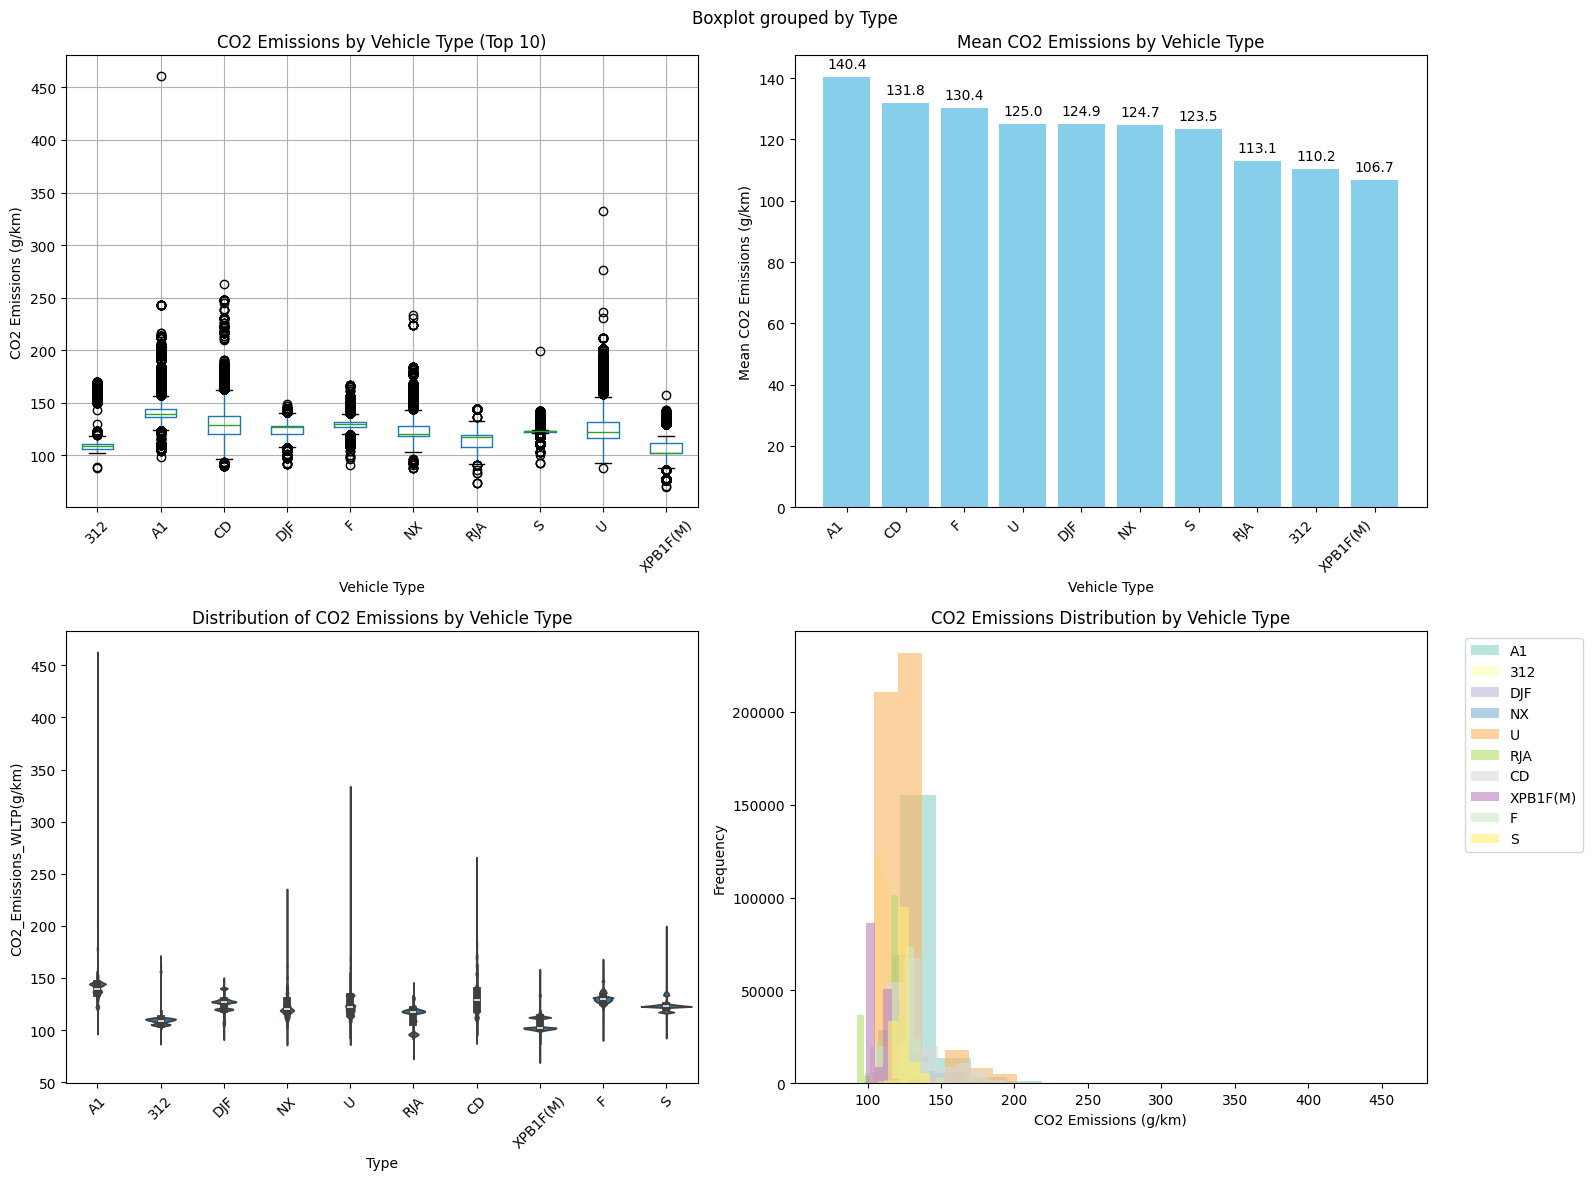


4. Effect Size:
Eta-squared: 0.4058
Effect size: Large

5. Post-hoc Analysis:
Significant pairwise comparisons (p < 0.05):
A1 vs 312: p-value = 0.000000, Mean difference = 30.19
A1 vs DJF: p-value = 0.000000, Mean difference = 15.48
A1 vs NX: p-value = 0.000000, Mean difference = 15.70
A1 vs U: p-value = 0.000000, Mean difference = 15.45
A1 vs RJA: p-value = 0.000000, Mean difference = 27.38
A1 vs CD: p-value = 0.000000, Mean difference = 8.60
A1 vs XPB1F(M): p-value = 0.000000, Mean difference = 33.70
A1 vs F: p-value = 0.000000, Mean difference = 10.05
A1 vs S: p-value = 0.000000, Mean difference = 16.98
312 vs DJF: p-value = 0.000000, Mean difference = 14.70
312 vs NX: p-value = 0.000000, Mean difference = 14.49
312 vs U: p-value = 0.000000, Mean difference = 14.74
312 vs RJA: p-value = 0.000000, Mean difference = 2.81
312 vs CD: p-value = 0.000000, Mean difference = 21.59
312 vs XPB1F(M): p-value = 0.000000, Mean difference = 3.51
312 vs F: p-value = 0.000000, Mean difference = 20

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway

# Focus on Top 10 Type categories only

# Select top 10 most common types
top_types = df_a['Type'].value_counts().head(10).index
df_filtered = df_a[df_a['Type'].isin(top_types)].copy()

print(f"Original dataset: {len(df_a)} records with {df_a['Type'].nunique()} unique types")
print(f"Filtered dataset: {len(df_filtered)} records with top 10 types")
print(f"Coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")


# 1. Exploratory Data Analysis
print(f"\n1. Basic Statistics:")
print(f"Filtered records: {len(df_filtered)}")
print(f"Vehicle types analyzed: {df_filtered['Type'].nunique()}")
print(f"Type distribution:")
print(df_filtered['Type'].value_counts())

# 2. Descriptive Statistics by Type
print("\n2. CO2 Emissions by Vehicle Type:")
co2_by_type = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_type)

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
type_groups = []
for vehicle_type in df_filtered['Type'].unique():
    if pd.notna(vehicle_type):  # Exclude NaN values
        group_data = df_filtered[df_filtered['Type'] == vehicle_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            type_groups.append(group_data)

# Perform ANOVA
f_stat, p_value = f_oneway(*type_groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: 0.05")
print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Box plot
df_filtered.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Type', ax=axes[0,0])
axes[0,0].set_title('CO2 Emissions by Vehicle Type (Top 10)')
axes[0,0].set_xlabel('Vehicle Type')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=45)

# Bar plot of means
type_means = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=False)
axes[0,1].bar(range(len(type_means)), type_means.values, color='skyblue')
axes[0,1].set_title('Mean CO2 Emissions by Vehicle Type')
axes[0,1].set_xlabel('Vehicle Type')
axes[0,1].set_ylabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_xticks(range(len(type_means)))
axes[0,1].set_xticklabels(type_means.index, rotation=45, ha='right')

# Add value labels on bars
for i, v in enumerate(type_means.values):
    axes[0,1].text(i, v + 2, f'{v:.1f}', ha='center', va='bottom')

# Violin plot
sns.violinplot(data=df_filtered, x='Type', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('Distribution of CO2 Emissions by Vehicle Type')
axes[1,0].tick_params(axis='x', rotation=45)

# Histogram overlay
colors = plt.cm.Set3(np.linspace(0, 1, len(df_filtered['Type'].unique())))
for i, vehicle_type in enumerate(df_filtered['Type'].unique()):
    if pd.notna(vehicle_type):
        data = df_filtered[df_filtered['Type'] == vehicle_type]['CO2_Emissions_WLTP(g/km)'].dropna()
        axes[1,1].hist(data, alpha=0.6, label=vehicle_type, bins=15, color=colors[i])

axes[1,1].set_title('CO2 Emissions Distribution by Vehicle Type')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
print(f"\n4. Effect Size:")
# Calculate eta-squared
ss_between = sum([len(group) * (group.mean() - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2 
                  for group in type_groups])
ss_total = ((df_filtered['CO2_Emissions_WLTP(g/km)'] - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
eta_squared = ss_between / ss_total
print(f"Eta-squared: {eta_squared:.4f}")
print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Post-hoc analysis (if ANOVA is significant)
if p_value < 0.05:
    print("\n5. Post-hoc Analysis:")
    from scipy.stats import tukey_hsd
    
    try:
        tukey_result = tukey_hsd(*type_groups)
        type_names = df_filtered['Type'].unique()
        print("Significant pairwise comparisons (p < 0.05):")
        
        significant_pairs = []
        for i, type1 in enumerate(type_names):
            for j, type2 in enumerate(type_names):
                if i < j and pd.notna(type1) and pd.notna(type2):
                    p_val = tukey_result.pvalue[i,j]
                    if p_val < 0.05:
                        mean1 = df_filtered[df_filtered['Type'] == type1]['CO2_Emissions_WLTP(g/km)'].mean()
                        mean2 = df_filtered[df_filtered['Type'] == type2]['CO2_Emissions_WLTP(g/km)'].mean()
                        significant_pairs.append((type1, type2, p_val, abs(mean1-mean2)))
                        print(f"{type1} vs {type2}: p-value = {p_val:.6f}, Mean difference = {abs(mean1-mean2):.2f}")
        
        if not significant_pairs:
            print("No significant pairwise differences found.")
            
    except Exception as e:
        print(f"Tukey's HSD could not be performed: {e}")

# 7. Summary Statistics Table
print("\n6. Summary Comparison:")
summary_stats = df_filtered.groupby('Type')['CO2_Emissions_WLTP(g/km)'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std Dev', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
]).round(2).sort_values('Mean', ascending=False)

print(summary_stats)

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between different vehicle types.")
    print("This suggests that vehicle type has a meaningful impact on CO2 emissions.")
    print(f"The effect size is {eta_squared:.4f}, which is considered {'small' if eta_squared < 0.01 else 'medium' if eta_squared < 0.06 else 'large'}.")
    
    # Identify highest and lowest emitting types
    highest_type = type_means.index[0]
    lowest_type = type_means.index[-1]
    print(f"Highest emitting type: {highest_type} ({type_means.iloc[0]:.1f} g/km)")
    print(f"Lowest emitting type: {lowest_type} ({type_means.iloc[-1]:.1f} g/km)")
    print(f"Difference: {type_means.iloc[0] - type_means.iloc[-1]:.1f} g/km")
else:
    print("There is NO statistically significant difference in CO2 emissions between vehicle types.")
    print("This suggests that vehicle type may not have a meaningful impact on CO2 emissions in this dataset.")

#### Does Innovative Technologies has a relationship with CO2 Emmissions


Null Hypothesis (H₀): There is no significant difference in mean CO2 emissions between different innovative technologies.
Alternative Hypothesis (H₁): There is a significant difference in mean CO2 emissions between different innovative technologies.
Expected: Different innovative technologies will show varying levels of CO2 emission reduction effectiveness.

Exploring Innovative_Technologies variable:
Total unique technologies: 268
Total records: 7870432

Technologies with ≥50 observations: 145
Technologies with ≥20 observations: 167
Technologies with ≥10 observations: 184
Technologies with <5 observations: 69

Top 15 most common technologies:
Innovative_Technologies
e2 29 37     776670
e9 29 37     497138
e6 37        486699
e1 29        443760
e13 29       377401
e13 29 37    300028
e8 29 37     290442
e2 28 29     284465
e3 33        199260
e2 37        198820
e5 29        160679
e19 29 37    144652
e2 29        124895
e9 32 37     122854
e13 37       118565
Name: count, dtype: int64

=== ANALYSIS SCOPE ===
Technologies with ≥20 observations: 167
Filtered dataset: 6185696 records
Coverage: 78.6% of original data

Reduced to top 15 technologies for manageable analysis:
Final dataset: 4526328 records
Final coverage: 57.5% of original data

1. Basic Statistics:
Technologies analyzed: 15
Technology distribution in filtered data:
Innovative_

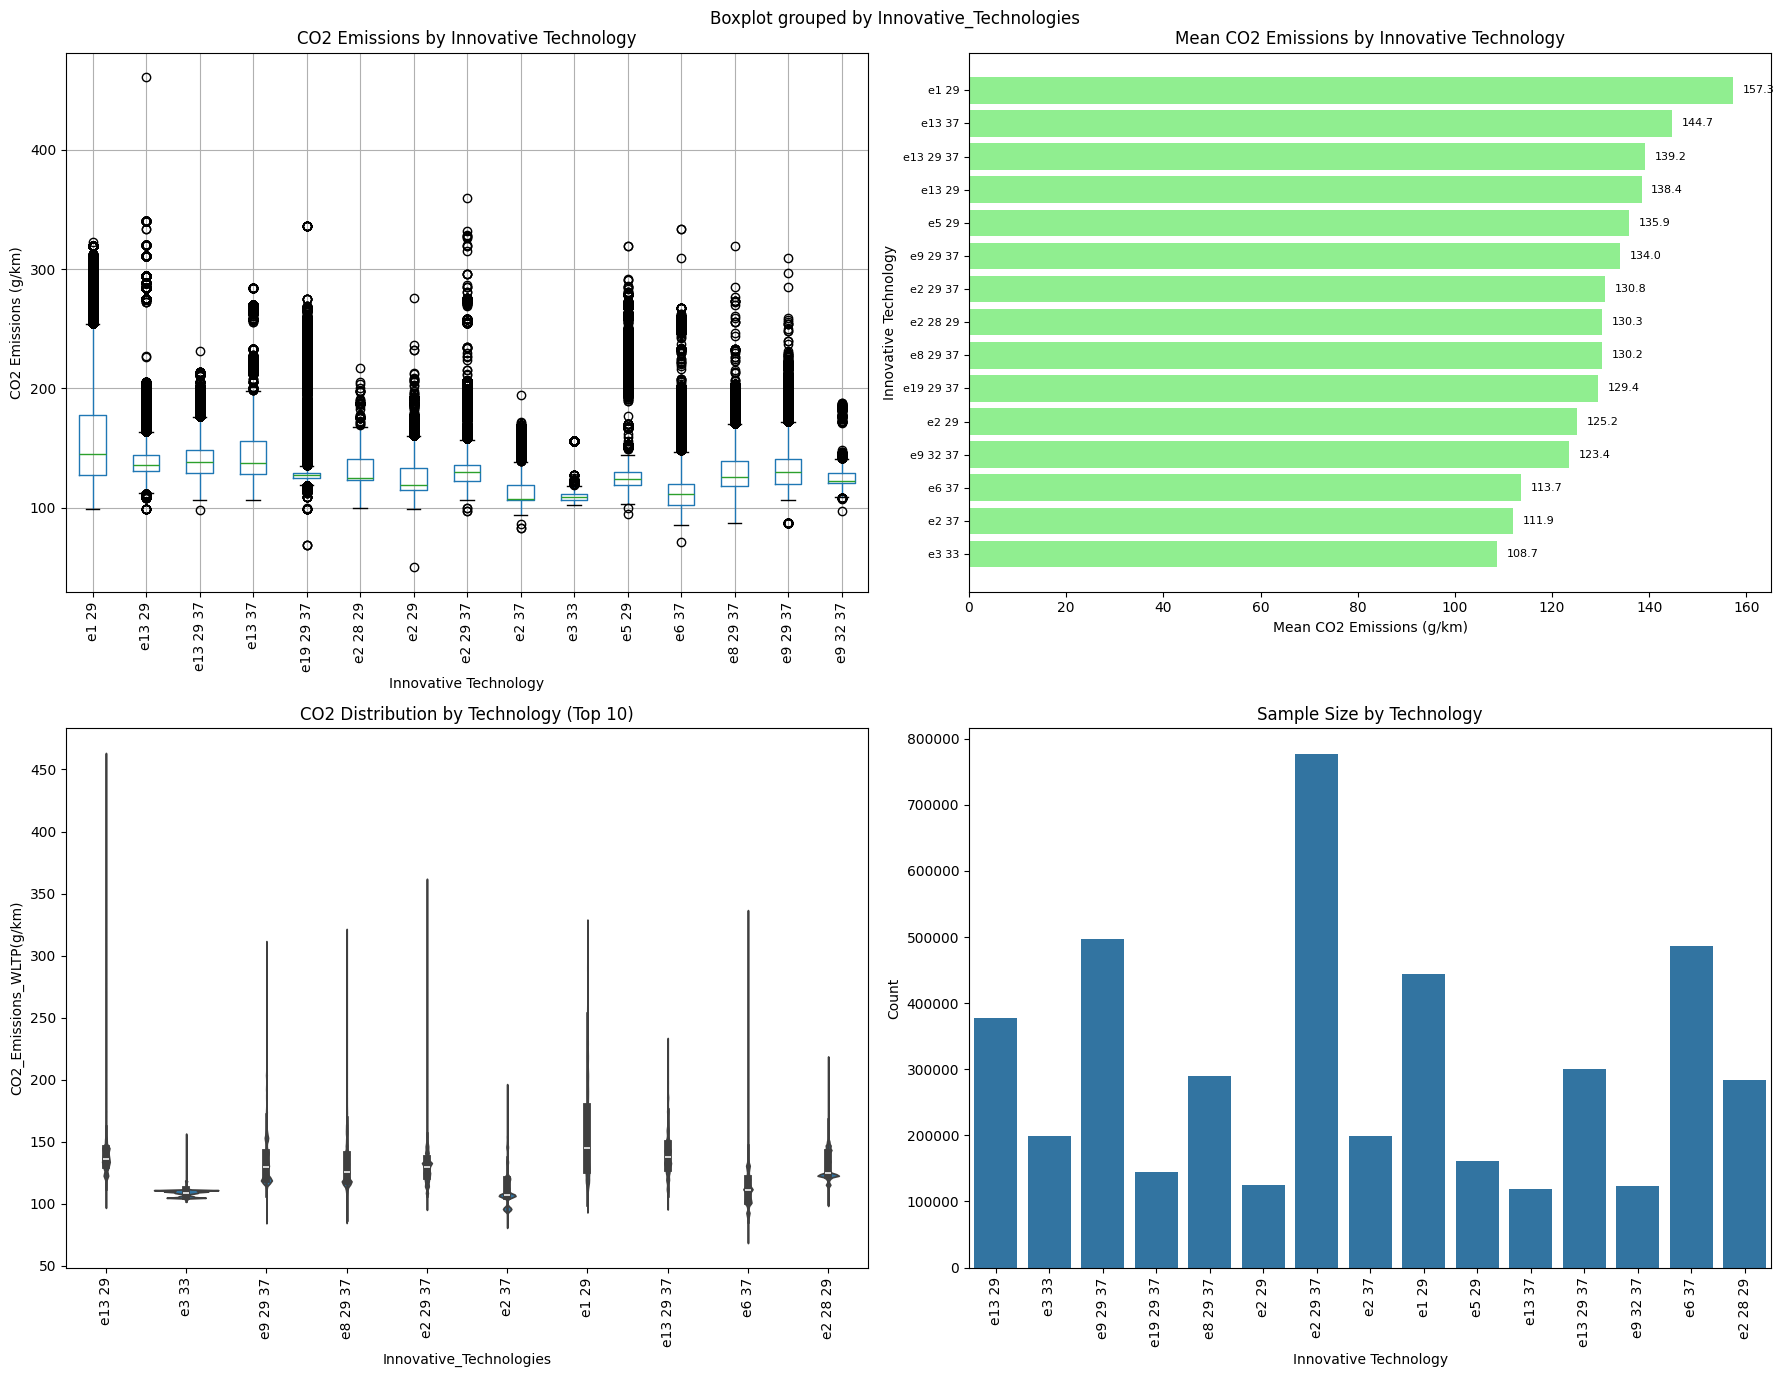


4. Effect Size:
Eta-squared: 0.2774
Effect size: Large

5. Technology Effectiveness Ranking (Lowest to Highest CO2):
                         Mean_CO2  Sample_Size
Innovative_Technologies                       
e3 33                       108.7       199260
e2 37                       111.9       198820
e6 37                       113.7       486699
e9 32 37                    123.4       122854
e2 29                       125.2       124895
e19 29 37                   129.4       144652
e8 29 37                    130.2       290442
e2 28 29                    130.3       284465
e2 29 37                    130.8       776670
e9 29 37                    134.0       497138
e5 29                       135.9       160679
e13 29                      138.4       377401
e13 29 37                   139.2       300028
e13 37                      144.7       118565
e1 29                       157.3       443760

6. Key Findings:
Most effective technology: e3 33 (108.72 g/km)
Least effective te

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway


# First, let's explore the distribution
print("Exploring Innovative_Technologies variable:")
print(f"Total unique technologies: {df_a['Innovative_Technologies'].nunique()}")
print(f"Total records: {len(df_a)}")

# Check the distribution
tech_counts = df_a['Innovative_Technologies'].value_counts()
print(f"\nTechnologies with ≥50 observations: {(tech_counts >= 50).sum()}")
print(f"Technologies with ≥20 observations: {(tech_counts >= 20).sum()}")
print(f"Technologies with ≥10 observations: {(tech_counts >= 10).sum()}")
print(f"Technologies with <5 observations: {(tech_counts < 5).sum()}")

# Show top 15 to see patterns
print(f"\nTop 15 most common technologies:")
print(tech_counts.head(15))

# Strategy: Use top categories that have sufficient sample size (≥20 observations)
min_observations = 20
top_technologies = tech_counts[tech_counts >= min_observations].index
df_filtered = df_a[df_a['Innovative_Technologies'].isin(top_technologies)].copy()

print(f"\n=== ANALYSIS SCOPE ===")
print(f"Technologies with ≥{min_observations} observations: {len(top_technologies)}")
print(f"Filtered dataset: {len(df_filtered)} records")
print(f"Coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")

# If still too many categories, further reduce to top 15
if len(top_technologies) > 15:
    top_15_technologies = tech_counts.head(15).index
    df_filtered = df_a[df_a['Innovative_Technologies'].isin(top_15_technologies)].copy()
    print(f"\nReduced to top 15 technologies for manageable analysis:")
    print(f"Final dataset: {len(df_filtered)} records")
    print(f"Final coverage: {len(df_filtered)/len(df_a)*100:.1f}% of original data")


# 1. Exploratory Data Analysis
print(f"\n1. Basic Statistics:")
print(f"Technologies analyzed: {df_filtered['Innovative_Technologies'].nunique()}")
print(f"Technology distribution in filtered data:")
filtered_tech_counts = df_filtered['Innovative_Technologies'].value_counts()
print(filtered_tech_counts)

# 2. Descriptive Statistics by Technology
print("\n2. CO2 Emissions by Innovative Technology:")
co2_by_tech = df_filtered.groupby('Innovative_Technologies')['CO2_Emissions_WLTP(g/km)'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)
print(co2_by_tech.sort_values('mean'))

# 3. Statistical Test - ANOVA
print("\n3. ANOVA Test:")
tech_groups = []
for technology in df_filtered['Innovative_Technologies'].unique():
    if pd.notna(technology):
        group_data = df_filtered[df_filtered['Innovative_Technologies'] == technology]['CO2_Emissions_WLTP(g/km)'].dropna()
        if len(group_data) > 0:
            tech_groups.append(group_data)

# Perform ANOVA
if len(tech_groups) > 1:
    f_stat, p_value = f_oneway(*tech_groups)
    print(f"F-statistic: {f_stat:.4f}")
    print(f"P-value: {p_value:.6f}")
    print(f"Significance level: 0.05")
    print(f"Result: {'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀'}")
else:
    print("Insufficient groups for ANOVA")
    p_value = 1.0

# 4. Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Box plot
df_filtered.boxplot(column='CO2_Emissions_WLTP(g/km)', by='Innovative_Technologies', ax=axes[0,0])
axes[0,0].set_title('CO2 Emissions by Innovative Technology')
axes[0,0].set_xlabel('Innovative Technology')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].tick_params(axis='x', rotation=90)

# Bar plot of means
tech_means = df_filtered.groupby('Innovative_Technologies')['CO2_Emissions_WLTP(g/km)'].mean().sort_values(ascending=True)
axes[0,1].barh(range(len(tech_means)), tech_means.values, color='lightgreen')
axes[0,1].set_title('Mean CO2 Emissions by Innovative Technology')
axes[0,1].set_xlabel('Mean CO2 Emissions (g/km)')
axes[0,1].set_ylabel('Innovative Technology')
axes[0,1].set_yticks(range(len(tech_means)))
axes[0,1].set_yticklabels(tech_means.index, fontsize=8)

# Add value labels on bars
for i, v in enumerate(tech_means.values):
    axes[0,1].text(v + 2, i, f'{v:.1f}', va='center', fontsize=8)

# Violin plot (show only top 10 for readability)
top_10_tech = filtered_tech_counts.head(10).index
df_top10 = df_filtered[df_filtered['Innovative_Technologies'].isin(top_10_tech)]
sns.violinplot(data=df_top10, x='Innovative_Technologies', y='CO2_Emissions_WLTP(g/km)', ax=axes[1,0])
axes[1,0].set_title('CO2 Distribution by Technology (Top 10)')
axes[1,0].tick_params(axis='x', rotation=90)

# Count plot
sns.countplot(data=df_filtered, x='Innovative_Technologies', ax=axes[1,1])
axes[1,1].set_title('Sample Size by Technology')
axes[1,1].set_xlabel('Innovative Technology')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

# 5. Effect Size (Eta-squared)
if len(tech_groups) > 1:
    print(f"\n4. Effect Size:")
    ss_between = sum([len(group) * (group.mean() - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2 
                      for group in tech_groups])
    ss_total = ((df_filtered['CO2_Emissions_WLTP(g/km)'] - df_filtered['CO2_Emissions_WLTP(g/km)'].mean())**2).sum()
    eta_squared = ss_between / ss_total
    print(f"Eta-squared: {eta_squared:.4f}")
    print(f"Effect size: {'Small' if eta_squared < 0.01 else 'Medium' if eta_squared < 0.06 else 'Large'}")

# 6. Technology Effectiveness Ranking
print("\n5. Technology Effectiveness Ranking (Lowest to Highest CO2):")
tech_effectiveness = df_filtered.groupby('Innovative_Technologies').agg({
    'CO2_Emissions_WLTP(g/km)': ['mean', 'count']
}).round(2)
tech_effectiveness.columns = ['Mean_CO2', 'Sample_Size']
tech_effectiveness = tech_effectiveness.sort_values('Mean_CO2')
print(tech_effectiveness)

# 7. Statistical significance analysis
if p_value < 0.05 and len(tech_groups) > 1:
    print("\n6. Key Findings:")
    best_tech = tech_effectiveness.index[0]
    worst_tech = tech_effectiveness.index[-1]
    best_co2 = tech_effectiveness.loc[best_tech, 'Mean_CO2']
    worst_co2 = tech_effectiveness.loc[worst_tech, 'Mean_CO2']
    
    print(f"Most effective technology: {best_tech} ({best_co2} g/km)")
    print(f"Least effective technology: {worst_tech} ({worst_co2} g/km)")
    print(f"Difference: {worst_co2 - best_co2:.1f} g/km")
    
    # Technologies significantly better than average
    overall_mean = df_filtered['CO2_Emissions_WLTP(g/km)'].mean()
    better_than_avg = tech_effectiveness[tech_effectiveness['Mean_CO2'] < overall_mean]
    print(f"\nTechnologies with below-average emissions ({overall_mean:.1f} g/km):")
    print(better_than_avg)

print("\n=== CONCLUSION ===")
if p_value < 0.05:
    print("There IS a statistically significant difference in CO2 emissions between different innovative technologies.")
    print("This confirms that innovative technologies have measurably different impacts on CO2 emissions.")
    if 'eta_squared' in locals():
        print(f"The effect size is {eta_squared:.4f}, indicating a {'small' if eta_squared < 0.01 else 'medium' if eta_squared < 0.06 else 'large'} practical impact.")
else:
    print("There is NO statistically significant difference in CO2 emissions between innovative technologies.")
    print("This suggests the technologies analyzed may have similar emission impacts, or more data may be needed.")

# 8. Additional insight: Check for patterns in technology names
print("\n7. Technology Pattern Analysis:")
all_techs = df_a['Innovative_Technologies'].dropna().astype(str)
print("Common patterns in technology names:")
patterns = {}
for tech in all_techs:
    words = tech.split()
    for word in words:
        if len(word) > 2:  # Ignore very short words
            patterns[word] = patterns.get(word, 0) + 1

# Show most common words/patterns
common_patterns = sorted(patterns.items(), key=lambda x: x[1], reverse=True)[:10]
print("Most common words in technology descriptions:")
for pattern, count in common_patterns:
    print(f"{pattern}: {count} occurrences")

#### Does the Engine_Capacity(cm3) has a relationship with CO2 Emmisions?

- Null Hypothesis (H₀): There is no linear relationship between engine capacity and CO2 emissions.
- Alternative Hypothesis (H₁): There is a significant linear relationship between engine capacity and CO2 emissions.
- Expected: Larger engine capacity should correlate with higher CO2 emissions due to increased fuel consumption.

=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===

1. Correlation Analysis:
Pearson Correlation Coefficient: 0.653558
Pearson P-value: 0.000000
Spearman Correlation Coefficient: 0.471378
Spearman P-value: 0.000000

Correlation Strength Interpretation:
Pearson: Strong positive linear relationship
Spearman: Moderate positive monotonic relationship

4. Statistical Significance (α = 0.05):
Pearson: Statistically significant
Spearman: Statistically significant

5. Coefficient of Determination (R²): 0.427138
   Interpretation: 42.71% of variance in CO2 emissions is explained by engine capacity


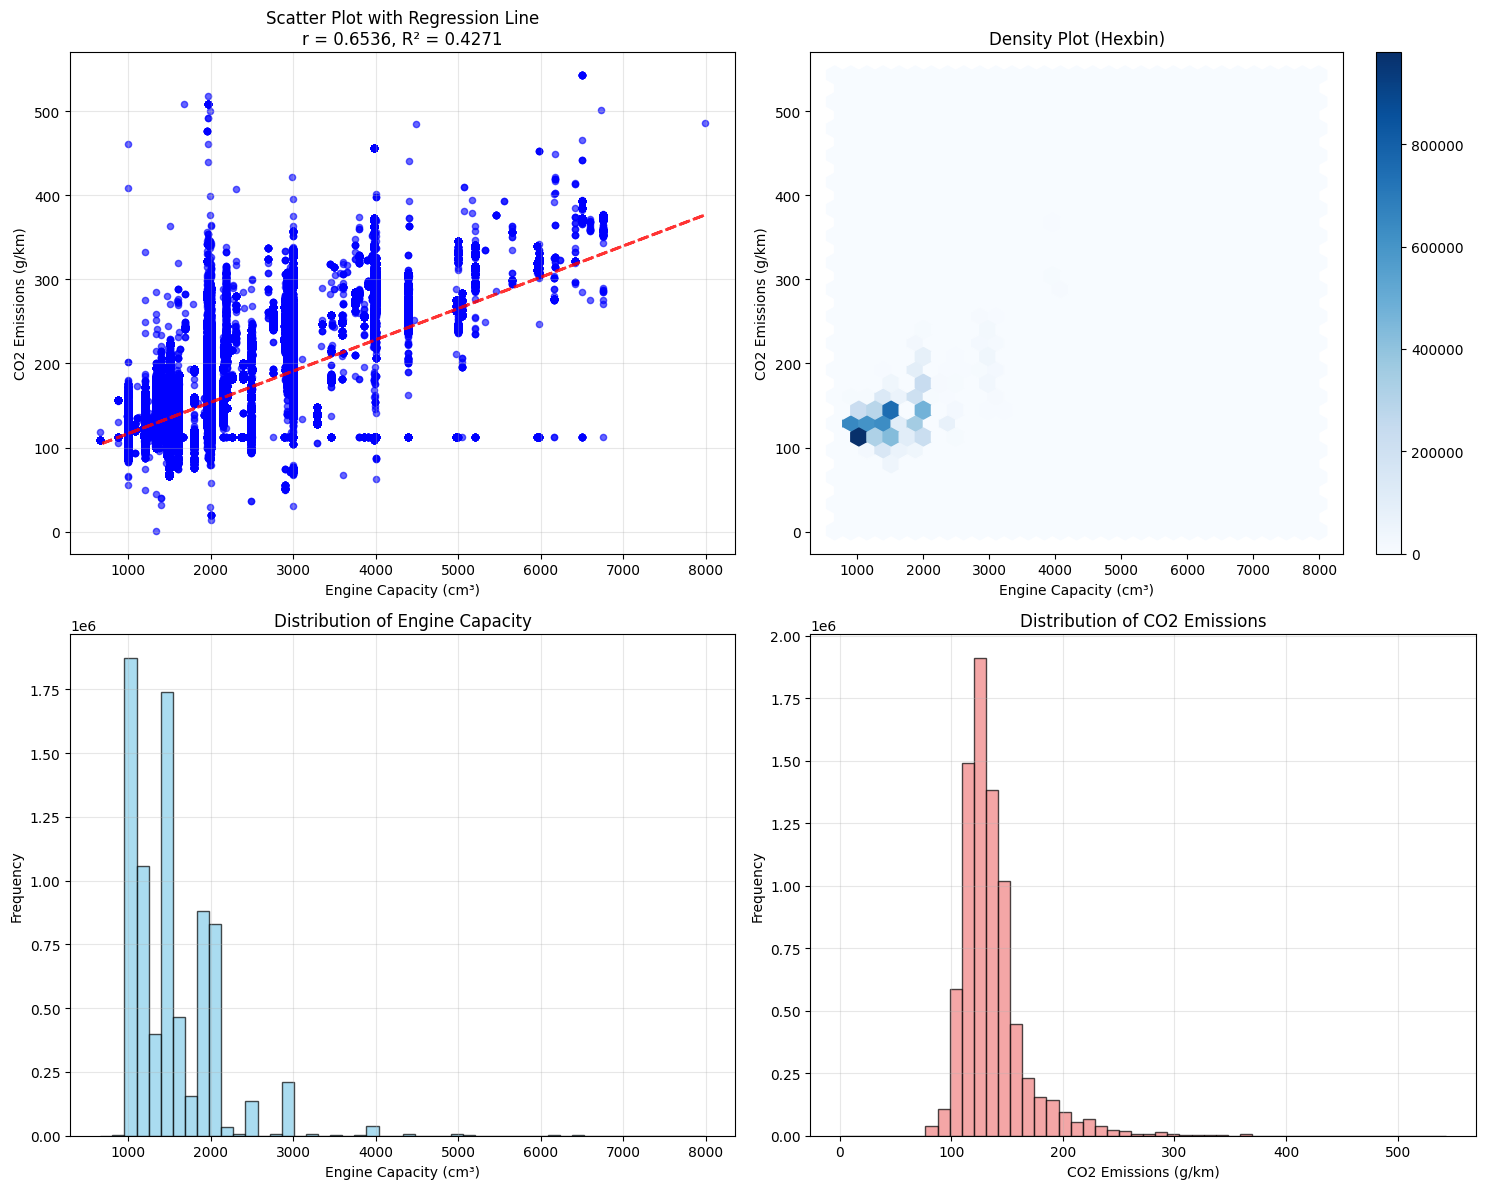


=== CONCLUSION ===
There IS a statistically significant linear relationship between engine capacity and CO2 emissions.
The correlation is strong and positive.
Engine capacity explains 42.71% of the variance in CO2 emissions.
As engine capacity increases, CO2 emissions tend to increase.

Note: If Spearman correlation (0.4714) is much different from Pearson correlation (0.6536),
this suggests a non-linear monotonic relationship might exist.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr

print("=== ENGINE CAPACITY AND CO2 EMISSIONS CORRELATION ANALYSIS ===")


# Remove missing values for analysis
df_clean = df_a[['Engine_Capacity(cm3)', 'CO2_Emissions_WLTP(g/km)']].dropna()


# 1. Correlation Analysis
print(f"\n1. Correlation Analysis:")

# Pearson correlation (linear relationship)
pearson_corr, pearson_p = pearsonr(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'])
print(f"Pearson Correlation Coefficient: {pearson_corr:.6f}")
print(f"Pearson P-value: {pearson_p:.6f}")

# Spearman correlation (monotonic relationship)
spearman_corr, spearman_p = spearmanr(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'])
print(f"Spearman Correlation Coefficient: {spearman_corr:.6f}")
print(f"Spearman P-value: {spearman_p:.6f}")

# Interpretation
print(f"\nCorrelation Strength Interpretation:")
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr < 0.1:
        return "Negligible"
    elif abs_corr < 0.3:
        return "Weak"
    elif abs_corr < 0.5:
        return "Moderate"
    elif abs_corr < 0.7:
        return "Strong"
    else:
        return "Very Strong"

print(f"Pearson: {interpret_correlation(pearson_corr)} {'positive' if pearson_corr > 0 else 'negative'} linear relationship")
print(f"Spearman: {interpret_correlation(spearman_corr)} {'positive' if spearman_corr > 0 else 'negative'} monotonic relationship")

# 4. Statistical Significance
alpha = 0.05
print(f"\n4. Statistical Significance (α = {alpha}):")
print(f"Pearson: {'Statistically significant' if pearson_p < alpha else 'Not statistically significant'}")
print(f"Spearman: {'Statistically significant' if spearman_p < alpha else 'Not statistically significant'}")

# 5. Coefficient of Determination (R²)
r_squared = pearson_corr**2
print(f"\n5. Coefficient of Determination (R²): {r_squared:.6f}")
print(f"   Interpretation: {r_squared*100:.2f}% of variance in CO2 emissions is explained by engine capacity")

# 6. Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
axes[0,0].scatter(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                  alpha=0.6, s=20, color='blue')
# Add regression line
z = np.polyfit(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 1)
p = np.poly1d(z)
axes[0,0].plot(df_clean['Engine_Capacity(cm3)'], p(df_clean['Engine_Capacity(cm3)']), 
               "r--", alpha=0.8, linewidth=2)
axes[0,0].set_xlabel('Engine Capacity (cm³)')
axes[0,0].set_ylabel('CO2 Emissions (g/km)')
axes[0,0].set_title(f'Scatter Plot with Regression Line\nr = {pearson_corr:.4f}, R² = {r_squared:.4f}')
axes[0,0].grid(True, alpha=0.3)

# Hexbin plot for density
hb = axes[0,1].hexbin(df_clean['Engine_Capacity(cm3)'], df_clean['CO2_Emissions_WLTP(g/km)'], 
                      gridsize=30, cmap='Blues')
axes[0,1].set_xlabel('Engine Capacity (cm³)')
axes[0,1].set_ylabel('CO2 Emissions (g/km)')
axes[0,1].set_title('Density Plot (Hexbin)')
plt.colorbar(hb, ax=axes[0,1])

# Distribution plots
axes[1,0].hist(df_clean['Engine_Capacity(cm3)'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[1,0].set_xlabel('Engine Capacity (cm³)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Distribution of Engine Capacity')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].hist(df_clean['CO2_Emissions_WLTP(g/km)'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,1].set_xlabel('CO2 Emissions (g/km)')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of CO2 Emissions')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



print("\n=== CONCLUSION ===")
if pearson_p < alpha:
    print("There IS a statistically significant linear relationship between engine capacity and CO2 emissions.")
    print(f"The correlation is {interpret_correlation(pearson_corr).lower()} and {'positive' if pearson_corr > 0 else 'negative'}.")
    print(f"Engine capacity explains {r_squared*100:.2f}% of the variance in CO2 emissions.")
    
    if pearson_corr > 0:
        print("As engine capacity increases, CO2 emissions tend to increase.")
    else:
        print("As engine capacity increases, CO2 emissions tend to decrease.")
        
else:
    print("There is NO statistically significant linear relationship between engine capacity and CO2 emissions.")
    print("Engine capacity does not appear to be a good predictor of CO2 emissions in this dataset.")

# Check for non-linear relationships
print(f"\nNote: If Spearman correlation ({spearman_corr:.4f}) is much different from Pearson correlation ({pearson_corr:.4f}),")
print("this suggests a non-linear monotonic relationship might exist.")